In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [7]:
def dataset_summary(df):
    print('=' * 50)
    print(f'SHAPE: {df.shape}')
    print('\nDTYPES & NULLS:')
    null_info = pd.DataFrame({
        'dtype': df.dtypes,
        'nulls': df.isnull().sum(),
        'null%': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(null_info[null_info['nulls'] > 0].to_string() if null_info['nulls'].sum() > 0 else 'No nulls')
    print(f'\nDUPLICATES: {df.duplicated().sum()}')
    print('\nNUMERICAL SUMMARY:')
    print(df.describe().round(2).to_string())
    print('\nCATEGORICAL UNIQUE VALUES:')
    for col in df.select_dtypes(include='object').columns:
        print(f'  {col}: {df[col].unique()}')
    print('=' * 50)

In [8]:
# Step 1.2 -> Load dataset
df = pd.read_csv('/content/Global Superstore.csv')
print(f'Shape: {df.shape}')
display(df.head())

Shape: (51290, 27)


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,Order Priority,Product ID,Product Name,Profit,Quantity,Region,Row ID,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Message Capacity, 5 3/6” x 11”",9.8418,3,West,31468,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [9]:
pd.set_option('display.max_rows', None)
df['Country'].value_counts()

,count
Country,
United States,9994
Australia,2837
France,2827
Mexico,2644
Germany,2065
China,1880
United Kingdom,1633
Brazil,1599
India,1555


In [10]:
# Step 2.1 -> Engineer feature
df['shipping_days'] = (pd.to_datetime(df['Ship Date']) - pd.to_datetime(df['Order Date'])).dt.days
display(df[['Order Date', 'Ship Date', 'shipping_days']].head())

,Order Date,Ship Date,shipping_days
0,00:00.0,00:00.0,0
1,00:00.0,00:00.0,0
2,00:00.0,00:00.0,0
3,00:00.0,00:00.0,0
4,00:00.0,00:00.0,0


In [11]:
# Step 2.2 -> Drop columns
drop_cols = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name', 'ji_lu-shu', 'Market2', 'City', 'State', 'Order Date', 'Ship Date']
df.drop(columns=drop_cols, inplace=True)
print(f'Remaining columns: {df.columns.tolist()}')

Remaining columns: ['Category', 'Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'shipping_days']


In [12]:
# Step 2.3 & 2.4 -> Check and handle nulls and duplicates
print(f'Nulls before: {df.isnull().sum().sum()}')
df.dropna(inplace=True)
print(f'Duplicates before: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Shape after cleaning: {df.shape}')

Nulls before: 0
Duplicates before: 0
Shape after cleaning: (51290, 16)


In [13]:
# Step 2.5 -> Check and fix data types
print(df.dtypes)
# All numerical columns (Sales, Quantity, Profit, Discount, Shipping Cost, Year, weeknum, shipping_days)
# appear correctly formatted based on previous info() output.

Category           object
Country            object
Discount          float64
Market             object
Order Priority     object
Profit            float64
Quantity            int64
Region             object
Sales               int64
Segment            object
Ship Mode          object
Shipping Cost     float64
Sub-Category       object
Year                int64
weeknum             int64
shipping_days       int64
dtype: object


In [14]:
# Step 2.6 -> Check Profit column
neg_profit = df[df['Profit'] < 0]
print(f"Rows with negative profit: {len(neg_profit)}")
print(f"Percentage of negative profit: {(len(neg_profit)/len(df)*100):.2f}%")

Rows with negative profit: 12544
Percentage of negative profit: 24.46%


In [15]:
# Step 2.7 -> Check Discount column range
print(f"Discount range: {df['Discount'].min()} to {df['Discount'].max()}")

Discount range: 0.0 to 0.85


In [16]:
# Step 2.8 -> Check Quantity and Shipping Cost for extreme outliers using IQR
for col in ['Quantity', 'Shipping Cost']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    print(f"Count of extreme outliers flagged in {col}: {len(outliers)}")

Count of extreme outliers flagged in Quantity: 877
Count of extreme outliers flagged in Shipping Cost: 5909


In [17]:
df[df['Shipping Cost']==df['Shipping Cost'].max()]

,Category,Country,Discount,Market,Order Priority,Profit,Quantity,Region,Sales,Segment,Ship Mode,Shipping Cost,Sub-Category,Year,weeknum,shipping_days
28451,Technology,United States,0.0,US,Critical,762.1845,7,East,2310,Consumer,Same Day,933.57,Accessories,2012,31,0


In [18]:
# Final cleaning summary
dataset_summary(df)

SHAPE: (51290, 16)

DTYPES & NULLS:
No nulls

DUPLICATES: 0

NUMERICAL SUMMARY:
       Discount    Profit  Quantity     Sales  Shipping Cost      Year   weeknum  shipping_days
count  51290.00  51290.00  51290.00  51290.00       51290.00  51290.00  51290.00        51290.0
mean       0.14     28.61      3.48    246.50          26.38   2012.78     31.29            0.0
std        0.21    174.34      2.28    487.57          57.30      1.10     14.43            0.0
min        0.00  -6599.98      1.00      0.00           0.00   2011.00      1.00            0.0
25%        0.00      0.00      2.00     31.00           2.61   2012.00     20.00            0.0
50%        0.00      9.24      3.00     85.00           7.79   2013.00     33.00            0.0
75%        0.20     36.81      5.00    251.00          24.45   2014.00     44.00            0.0
max        0.85   8399.98     14.00  22638.00         933.57   2014.00     53.00            0.0

CATEGORICAL UNIQUE VALUES:
  Category: ['Office Supplie

## Phase 3: Univariate Analysis
### Step 3.1 → Target Variable Analysis (Profit)

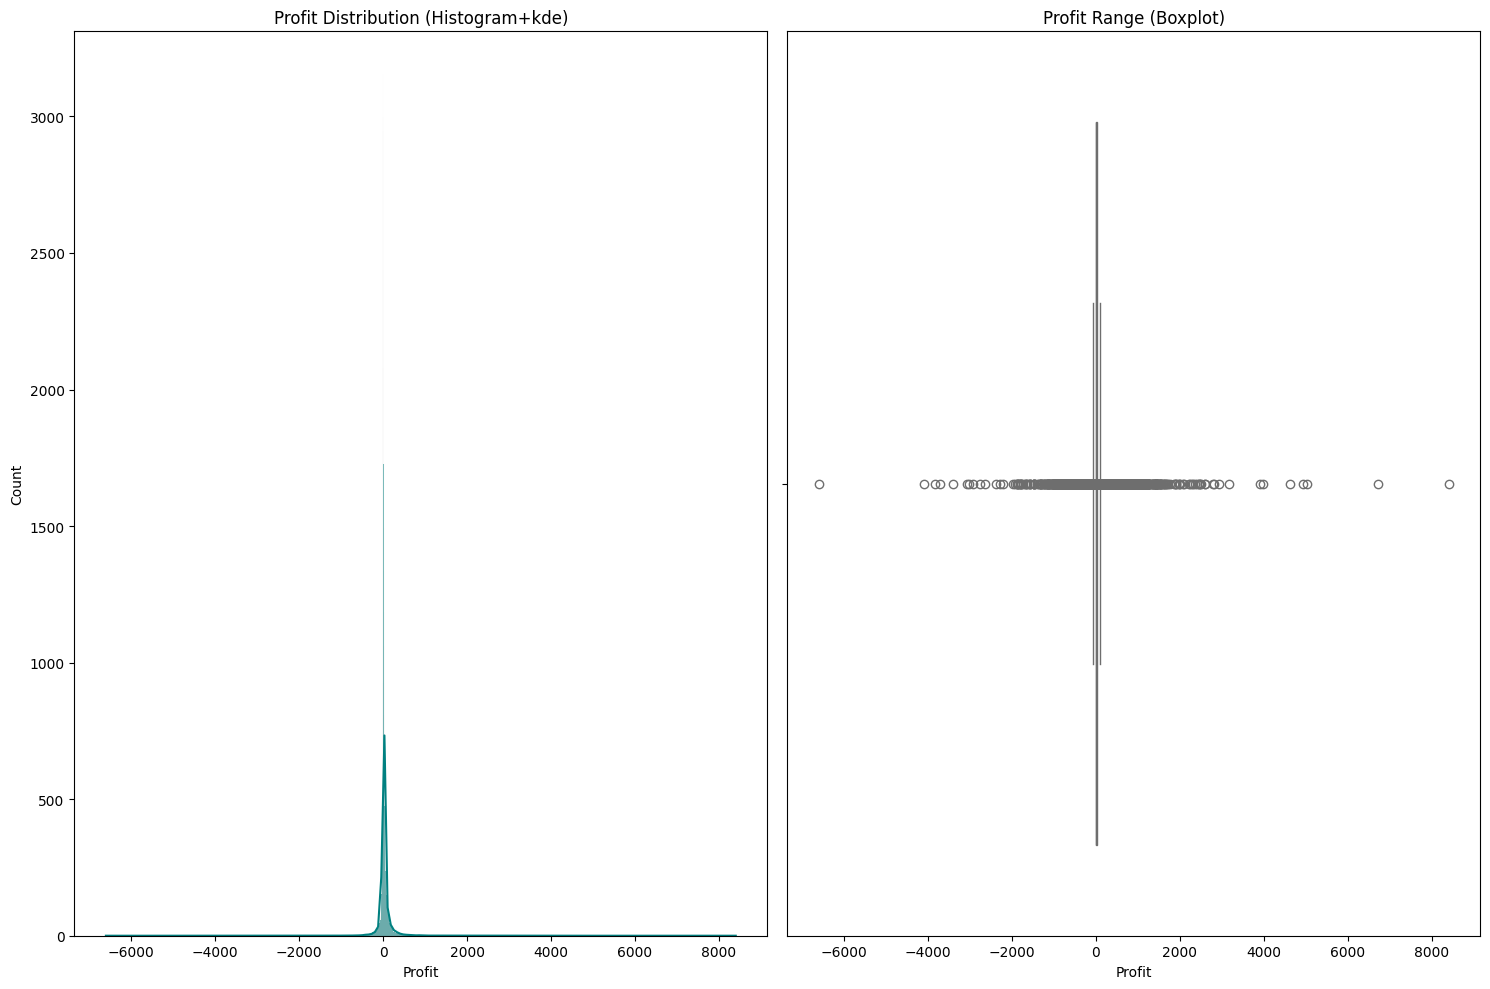

Skewness: 4.16
Kurtosis: 291.41
Percentage of Negative Profits (Losses): 24.46%
Percentage of Zero Profits (Break-even): 1.30%


In [19]:
import scipy.stats as stats

# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Histogram + KDE
sns.histplot(df['Profit'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Profit Distribution (Histogram+kde)')

# Boxplot
sns.boxplot(x=df['Profit'], ax=axes[1], color='lightcoral')
axes[1].set_title('Profit Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Skewness: {df['Profit'].skew():.2f}")
print(f"Kurtosis: {df['Profit'].kurt():.2f}")

neg_p_pct = (df['Profit'] < 0).mean() * 100
zero_p_pct = (df['Profit'] == 0).mean() * 100

print(f"Percentage of Negative Profits (Losses): {neg_p_pct:.2f}%")
print(f"Percentage of Zero Profits (Break-even): {zero_p_pct:.2f}%")

### Insights & Business Interpretation:
*   **Extreme Volatility:** The high Kurtosis and long tails in the boxplot indicate significant outliers. The business experiences extreme individual losses (down to -$6,600) and high gains (up to $8,400).
*   **High-Risk Operations:** A **24.46% loss rate** is quite high for a retail environment, suggesting that nearly 1 in 4 transactions is losing money. This points to unstable profitability that needs deep-diving in the bivariate phase (likely linked to Discounts).
*   **Modeling Note:** The distribution is highly skewed. For future regression tasks, a transformation (like a Power Transformer or handling outliers) will be necessary as the raw Profit variable is non-normal.

### Step 3.2 → Sales Distribution Analysis

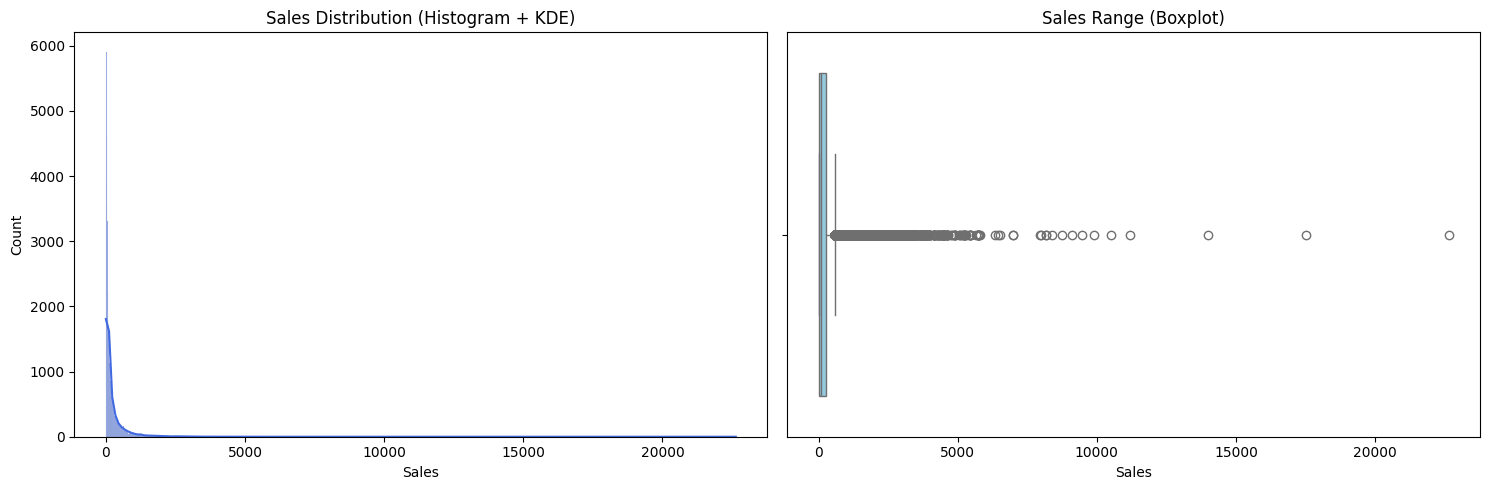

Sales Skewness: 8.14
Median Sales: 85.0
Mean Sales: 246.50


In [20]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['Sales'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Sales Distribution (Histogram + KDE)')

# Boxplot
sns.boxplot(x=df['Sales'], ax=axes[1], color='skyblue')
axes[1].set_title('Sales Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Sales Skewness: {df['Sales'].skew():.2f}")
print(f"Median Sales: {df['Sales'].median()}")
print(f"Mean Sales: {df['Sales'].mean():.2f}")

### Insights & Business Interpretation:
*   **High Positive Skew:** The distribution shows that the vast majority of orders involve low sales amounts (Median is much lower than the Mean), while a few extremely large transactions pull the average up.
*   **Transaction Profile:** The business is primarily driven by small-to-medium transactions, but the extreme outliers in the boxplot suggest that a small percentage of orders contribute significantly to total revenue.
*   **Risk Note:** Heavy reliance on these large 'outlier' transactions could create revenue instability if those specific clients or products are lost.

### Step 3.3 → Discount Distribution Analysis

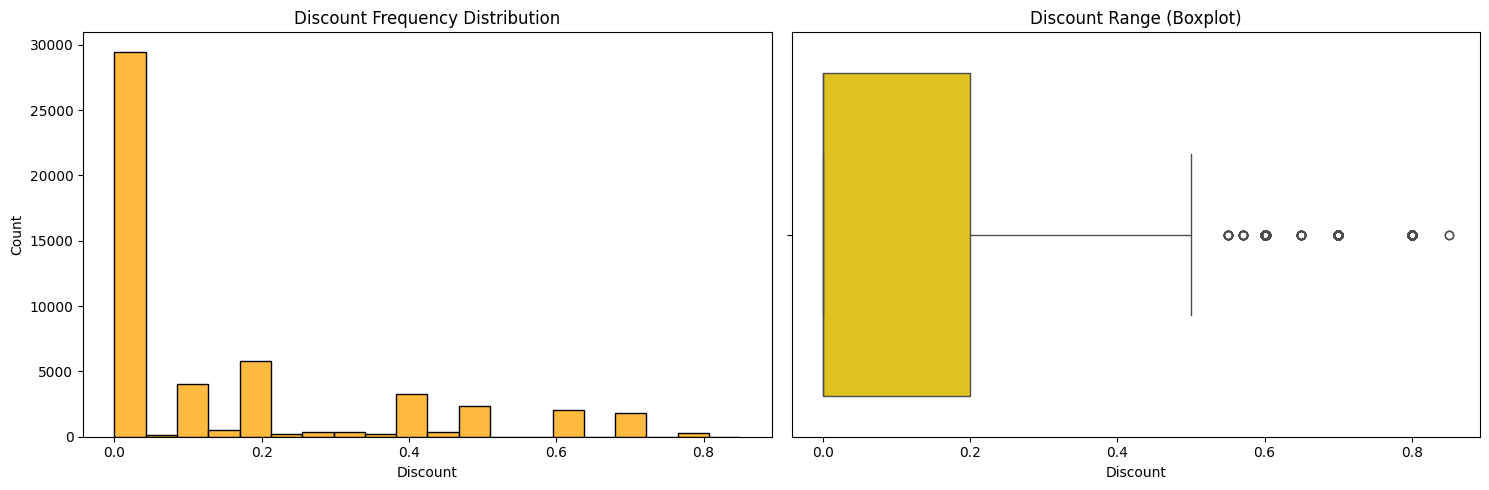

Top 10 Discount Levels by Frequency:
Discount
0.00    29009
0.20     4998
0.10     4068
0.40     3177
0.60     2006
0.70     1786
0.50     1633
0.17      735
0.47      725
0.15      541
Name: count, dtype: int64


In [21]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Countplot for discrete discount levels
sns.histplot(df['Discount'], bins=20, ax=axes[0], color='orange')
axes[0].set_title('Discount Frequency Distribution')

# Boxplot
sns.boxplot(x=df['Discount'], ax=axes[1], color='gold')
axes[1].set_title('Discount Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Value counts for major discount levels
print("Top 10 Discount Levels by Frequency:")
print(df['Discount'].value_counts().head(10))

### Insights & Business Interpretation:
*   **Zero-Discount Strategy:** A significant portion of transactions occur at 0% discount, which likely represents the core profitable segment of the business.
*   **Aggressive Discounting:** There are clear 'spikes' at specific intervals (e.g., 20%, 50%). Discounts above 20-30% in retail often wipe out profit margins entirely.
*   **PPT Insight:** The heavy tail of discounts up to 85% is a major red flag. This aggressive discounting strategy is almost certainly correlated with the 24% loss rate we observed earlier and should be a primary focus for business optimization.

### Step 3.4 → Quantity Analysis

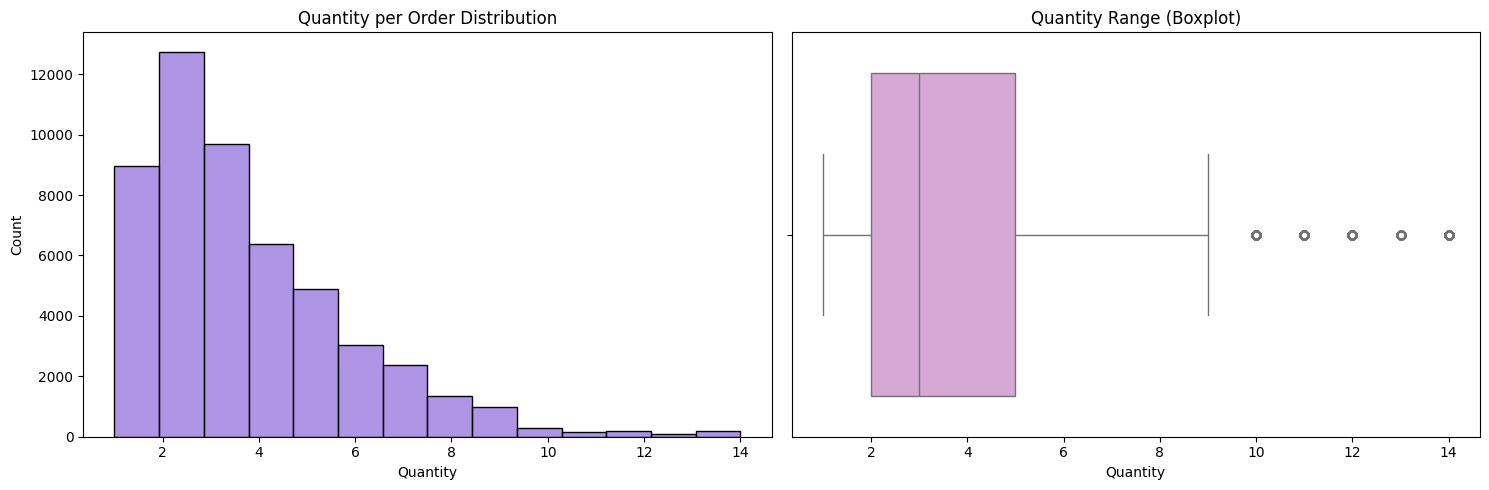

Common Order Sizes (Mode): 2
Average Quantity: 3.48


In [22]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(df['Quantity'], bins=14, ax=axes[0], color='mediumpurple')
axes[0].set_title('Quantity per Order Distribution')

# Boxplot
sns.boxplot(x=df['Quantity'], ax=axes[1], color='plum')
axes[1].set_title('Quantity Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Common Order Sizes (Mode): {df['Quantity'].mode()[0]}")
print(f"Average Quantity: {df['Quantity'].mean():.2f}")

### Insights & Business Interpretation:
*   **Small-Order Driven:** Most orders consist of 2 to 5 items. The business is primarily small-order driven rather than catering to heavy bulk purchasers.
*   **Consistency:** The distribution is relatively tight, though orders of 10+ items do exist as outliers. This suggests a very standard consumer-level purchasing behavior across the dataset.

### Step 3.5 → Shipping Cost Analysis

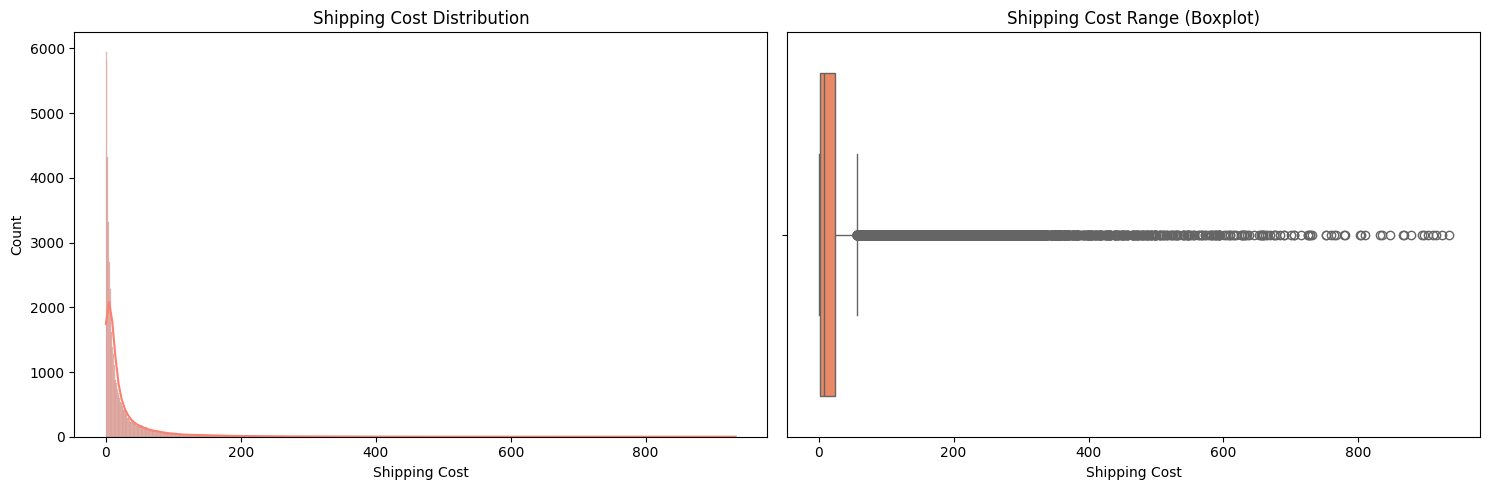

Shipping Cost Skewness: 5.86
Median Shipping Cost: 7.79


In [23]:
# 1. Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(df['Shipping Cost'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Shipping Cost Distribution')

# Boxplot
sns.boxplot(x=df['Shipping Cost'], ax=axes[1], color='coral')
axes[1].set_title('Shipping Cost Range (Boxplot)')

plt.tight_layout()
plt.show()

# 2. Statistics
print(f"Shipping Cost Skewness: {df['Shipping Cost'].skew():.2f}")
print(f"Median Shipping Cost: {df['Shipping Cost'].median():.2f}")

### Insights & Business Interpretation:
*   **High Skewness:** Similar to Sales, Shipping Cost is highly positively skewed. Most shipments are low-cost (Median ~7.8), but a significant number of extreme outliers exist.
*   **Logistics Concentration:** A small percentage of shipments are disproportionately expensive (reaching over $900). This suggests that specific high-priority or heavy-weight orders are dominating the logistics budget and may need separate management.

### Step 3.6 → Category-Level Distribution Analysis

/tmp/ipykernel_2182/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_2182/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_2182/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_2182/1254260431.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)


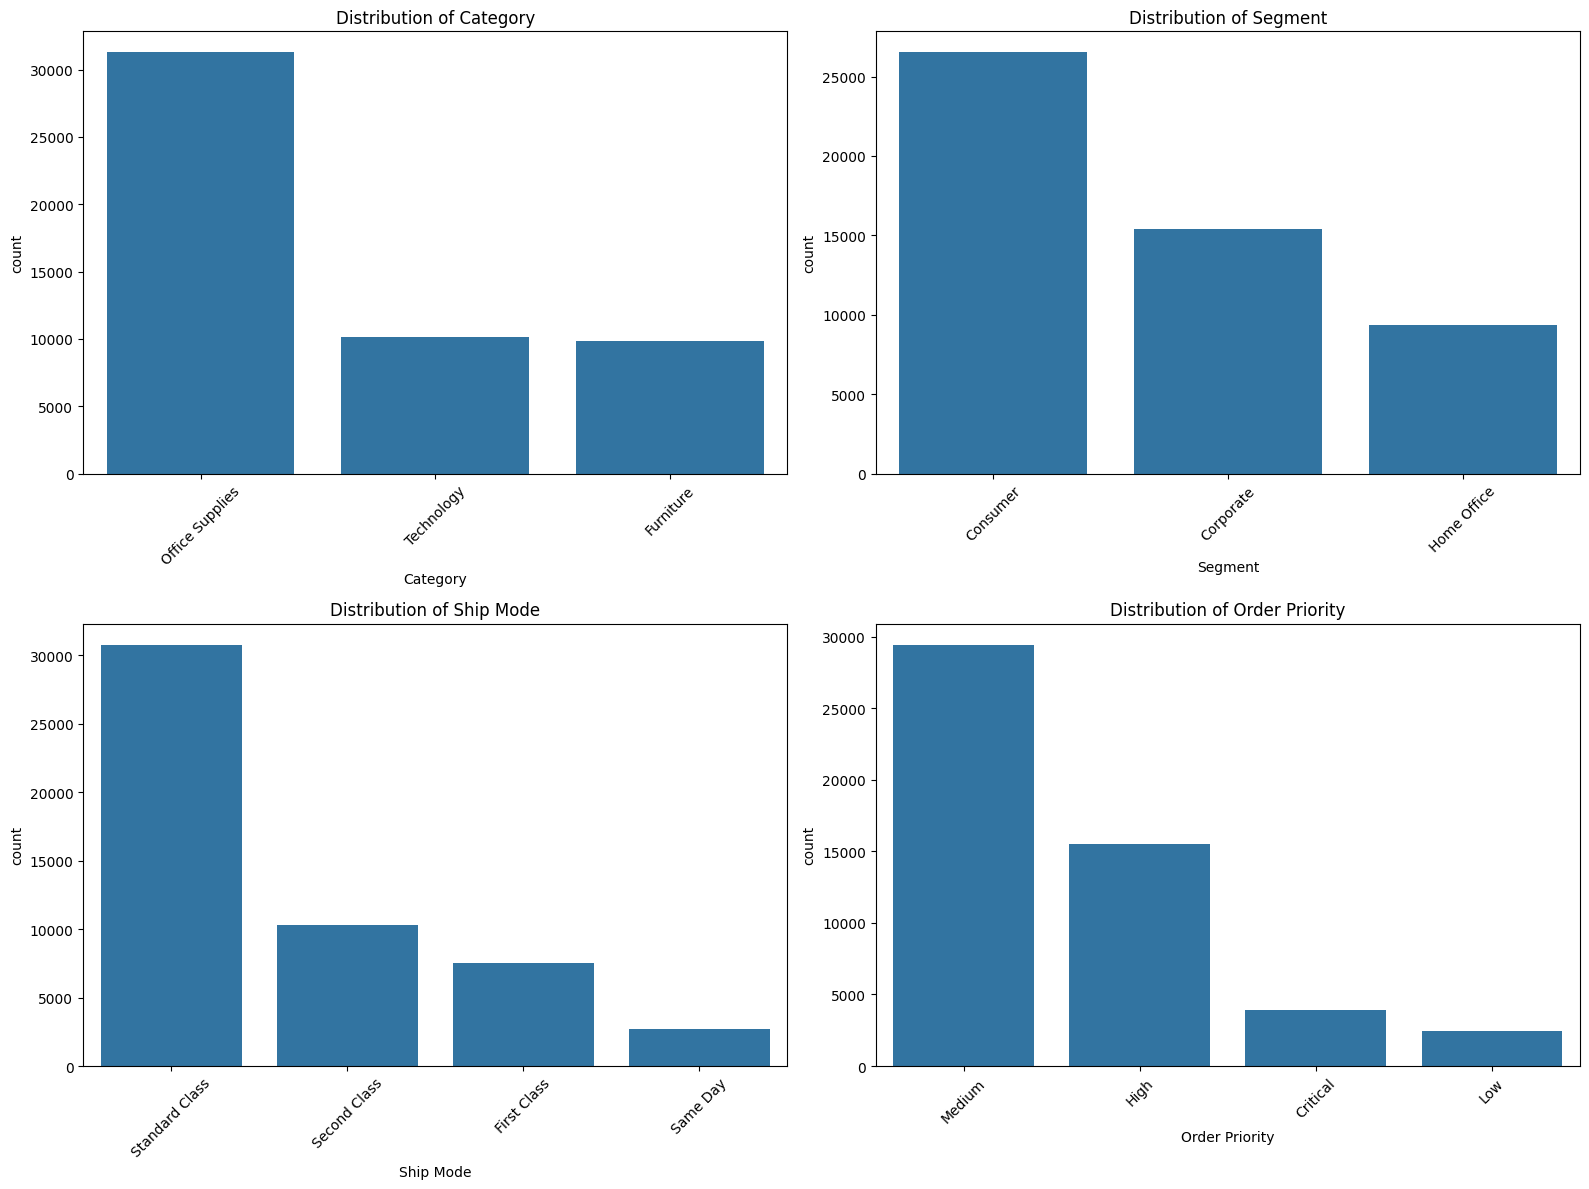

In [24]:
cat_cols = ['Category', 'Segment', 'Ship Mode', 'Order Priority']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Insights & Business Interpretation:
*   **Dominant Category:** 'Office Supplies' is the clear volume leader, suggesting a business model centered on high-frequency, smaller-value utility items.
*   **Customer Segment:** The 'Consumer' segment is the largest, followed by Corporate, indicating a strong B2C presence.
*   **Operational Behavior:** 'Standard Class' is overwhelmingly the preferred shipping mode, showing that customers prioritize cost-savings over speed.
*   **Urgency Levels:** Most orders fall under 'Medium' priority, with 'Critical' orders being the minority, which aligns with the preference for Standard Class shipping.

### Step 3.7 → Sub-Category Frequency Analysis

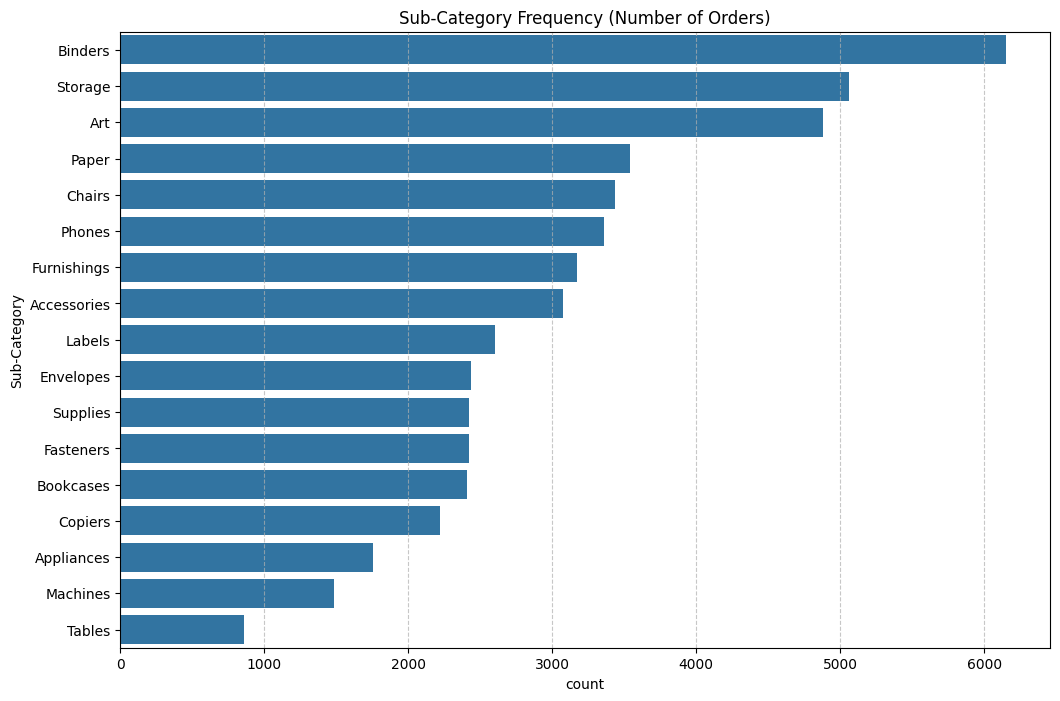

Top 5 Sub-Categories by Volume:
Sub-Category
Binders    6152
Storage    5059
Art        4883
Paper      3538
Chairs     3434
Name: count, dtype: int64

Bottom 5 Sub-Categories by Volume:
Sub-Category
Bookcases     2411
Copiers       2223
Appliances    1755
Machines      1486
Tables         861
Name: count, dtype: int64


In [25]:
plt.figure(figsize=(12, 8))
# Using hue=Sub-Category and legend=False
sns.countplot(data=df, y='Sub-Category',
              order=df['Sub-Category'].value_counts().index,
              legend=False)
plt.title('Sub-Category Frequency (Number of Orders)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Sub-Categories by Volume:")
print(df['Sub-Category'].value_counts().head(5))
print("\nBottom 5 Sub-Categories by Volume:")
print(df['Sub-Category'].value_counts().tail(5))

### Insights & Business Interpretation:
*   **High Volume Dependency:** The top sub-categories like Binders, Storage, and Art represent high-frequency office consumables. These are likely the 'bread and butter' of the business.
*   **Specialized Goods:** The bottom list includes 'Tables' and 'Copiers'. While low in frequency, these usually represent much higher unit sales prices, which we will verify in the bivariate phase.
*   **Concentration Risk:** The business is heavily reliant on Binders and Paper. Any supply chain disruption in these specific areas would impact nearly 20% of the total order volume.

## Potential Surprising Insights Discovered So Far

*   **Aggressive Loss Profile:** Nearly **25% of all transactions are unprofitable**, indicating that the business might be sacrificing margin for market share or miscalculating localized costs.
*   **Extreme Outlier Sensitivity:** Both Sales and Shipping Costs are heavily skewed (Skewness > 5). A very tiny fraction of orders generates massive logistical costs and revenue, making the overall average figures misleading for standard operations.
*   **Discounting Red Flag:** Significant spikes at high discount levels (50%+) suggest a culture of aggressive promotions which likely correlates directly with the high loss percentage.
*   **Standardization Over Speed:** Despite 'Critical' orders existing, the vast majority of the business flows through 'Standard Class' shipping, suggesting the customer base is highly price-sensitive rather than time-sensitive.

## Phase 4: Bivariate Analysis
### Step 4.1 → Discount vs Profit Analysis

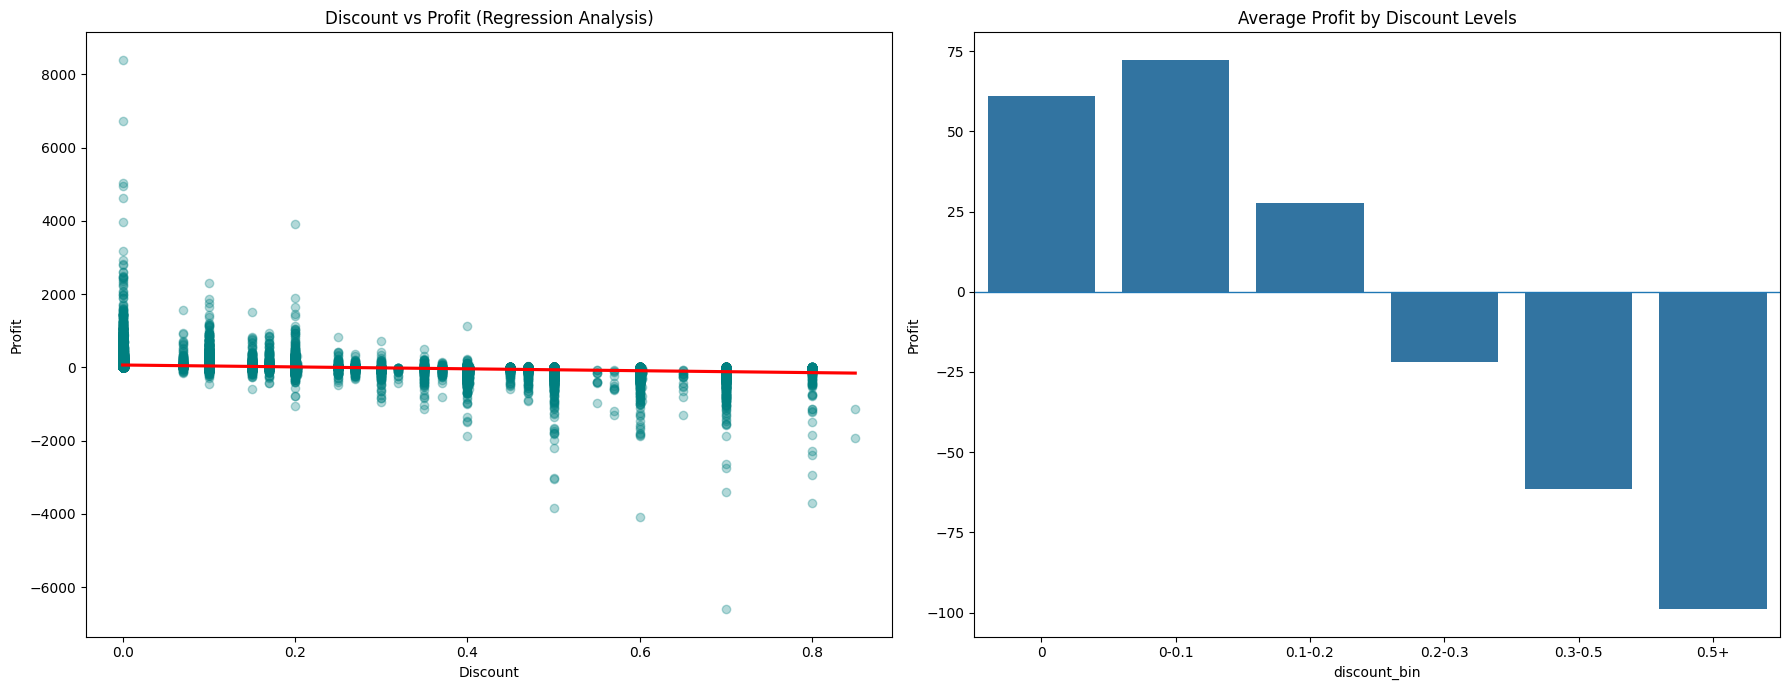

Correlation between Discount and Profit: -0.3165


In [26]:
import numpy as np

# 1. Grouped Analysis: Binning Discounts
bins = [-0.01, 0.0, 0.1, 0.2, 0.3, 0.5, 1.0]
labels = ['0', '0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.5', '0.5+']
df['discount_bin'] = pd.cut(df['Discount'], bins=bins, labels=labels)

discount_profit_stats = df.groupby('discount_bin', observed=False)['Profit'].mean().reset_index()

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatterplot with Trendline
sns.regplot(data=df, x='Discount', y='Profit', ax=axes[0],
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Discount vs Profit (Regression Analysis)')

# Barplot: Average Profit by Discount Bin
sns.barplot(data=discount_profit_stats, x='discount_bin', y='Profit', ax=axes[1])
axes[1].axhline(0, linewidth=1)
axes[1].set_title('Average Profit by Discount Levels')

plt.tight_layout()
plt.show()

# 3. Correlation
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr:.4f}")

### Insights & Business Interpretation:
*   **The Profitability Cliff:** Profit consistently becomes negative once discounts exceed **20%**. Beyond the 20-30% bin, the average loss accelerates dramatically, proving that aggressive discounting is the primary driver of business losses.
*   **Destructive Revenue Growth:** There is clear evidence of **"buying revenue at the cost of losses"**. The downward trendline confirms that for every unit increase in discount, the business suffers a predictable decline in profit, with 50%+ discounts resulting in catastrophic margins.
*   **Presentation-Worthy Insight:** The business is currently using a "Value-Destruction" pricing strategy for a quarter of its orders. Eliminating or capping discounts at 20% could theoretically turn the majority of loss-making transactions into break-even or profitable ones.

### Step 4.2 → Sales vs Profit Analysis

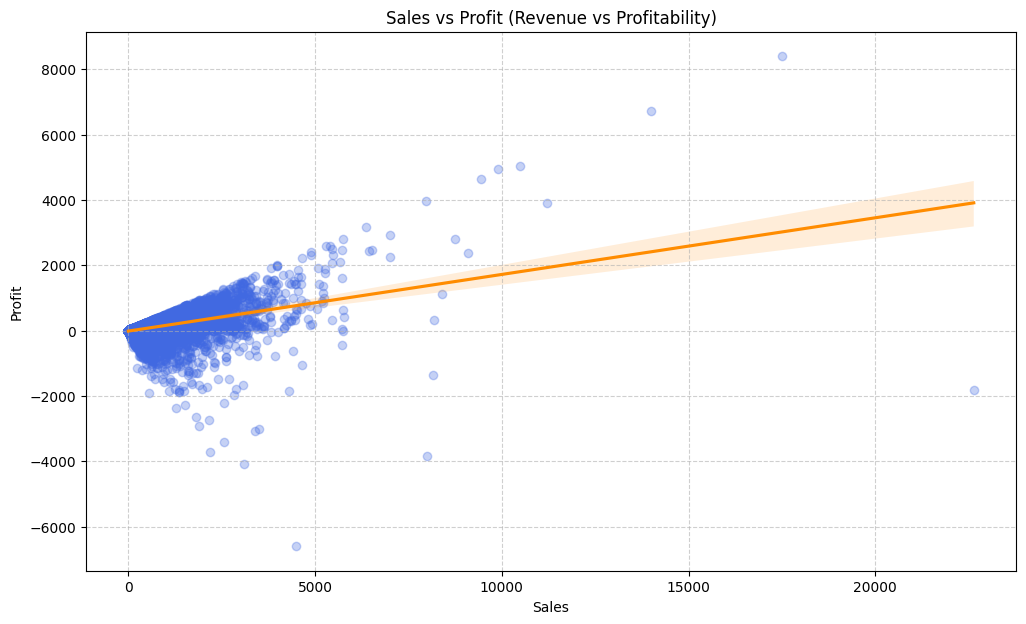

Correlation between Sales and Profit: 0.4849
Number of Top 5% Revenue orders that are loss-making: 422


In [27]:
# 1. Visualization
plt.figure(figsize=(12, 7))
sns.regplot(data=df, x='Sales', y='Profit',
            scatter_kws={'alpha':0.3, 'color':'royalblue'},
            line_kws={'color':'darkorange'})

plt.title('Sales vs Profit (Revenue vs Profitability)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Correlation and Outlier Check
sales_profit_corr = df['Sales'].corr(df['Profit'])
print(f"Correlation between Sales and Profit: {sales_profit_corr:.4f}")

# Identifying high-revenue/loss-making orders
high_rev_loss = df[(df['Sales'] > df['Sales'].quantile(0.95)) & (df['Profit'] < 0)]
print(f"Number of Top 5% Revenue orders that are loss-making: {len(high_rev_loss)}")

### Insights & Business Interpretation:
*   **High Revenue ≠ High Profitability:** The weak correlation and the wide spread in the scatterplot show that increasing sales does not guaranteed profit. There are numerous high-revenue transactions (outliers on the far right) that sit deep in the negative profit zone.
*   **Efficiency Trap:** We identified that several top-tier revenue orders are actually loss-making. This confirms that the business is sometimes scale-inefficient—likely due to the aggressive discounting found in the previous step.
*   **Presentation-Worthy Insight:** "Revenue is Vanity, Profit is Sanity." The business has a significant volume of high-value orders that are essentially subsidizing losses for the customer rather than generating value for the company.

### Step 4.3 → Category vs Profit Analysis

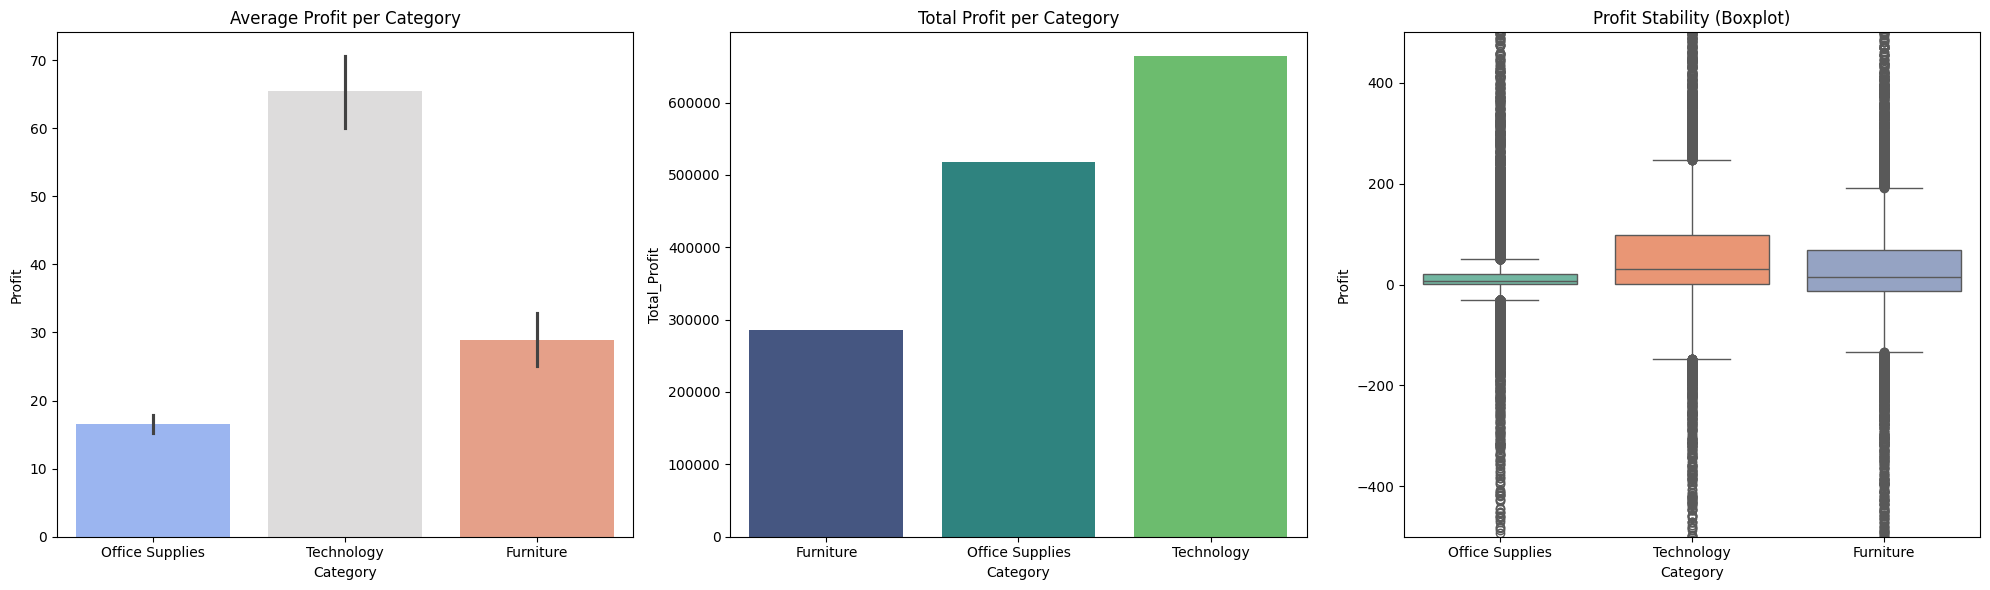

,Category,Average_Profit,Total_Profit,Total_Sales
0,Furniture,28.878567,285204.72380,4110884
1,Office Supplies,16.578961,518473.83430,3787330
2,Technology,65.454958,663778.73318,4744691


In [28]:
# 1. Aggregating Category Data
cat_analysis = df.groupby('Category').agg({
    'Profit': ['mean', 'sum'],
    'Sales': 'sum'
}).reset_index()
cat_analysis.columns = ['Category', 'Average_Profit', 'Total_Profit', 'Total_Sales']

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Average Profit per Category
sns.barplot(data=df, x='Category', y='Profit', ax=axes[0], palette='coolwarm', hue='Category', legend=False)
axes[0].set_title('Average Profit per Category')

# Total Profit per Category
sns.barplot(data=cat_analysis, x='Category', y='Total_Profit', ax=axes[1], palette='viridis', hue='Category', legend=False)
axes[1].set_title('Total Profit per Category')

# Boxplot for Stability Analysis
sns.boxplot(data=df, x='Category', y='Profit', ax=axes[2], palette='Set2', hue='Category', legend=False)
axes[2].set_title('Profit Stability (Boxplot)')
axes[2].set_ylim(-500, 500) # Zooming in to see the interquartile range clearly

plt.tight_layout()
plt.show()

display(cat_analysis)

### Insights & Business Interpretation:
*   **Technology is the Profit Engine:** While 'Office Supplies' has the highest volume, **Technology** delivers the highest average and total profit, indicating it is the most value-dense category.
*   **Furniture Stability Issues:** The boxplot and average profit charts reveal that **Furniture** is the most unstable category. It has the lowest average profit, likely due to high shipping costs and thin margins, making it the riskiest part of the portfolio.
*   **Presentation-Worthy Insight:** "Volume vs Value" - The business relies on Office Supplies for transaction count, but depends on Technology for actual bankable profit. Furniture is currently a low-margin drag on the overall business health.

### Step 4.4 → Sub-Category vs Profit Analysis

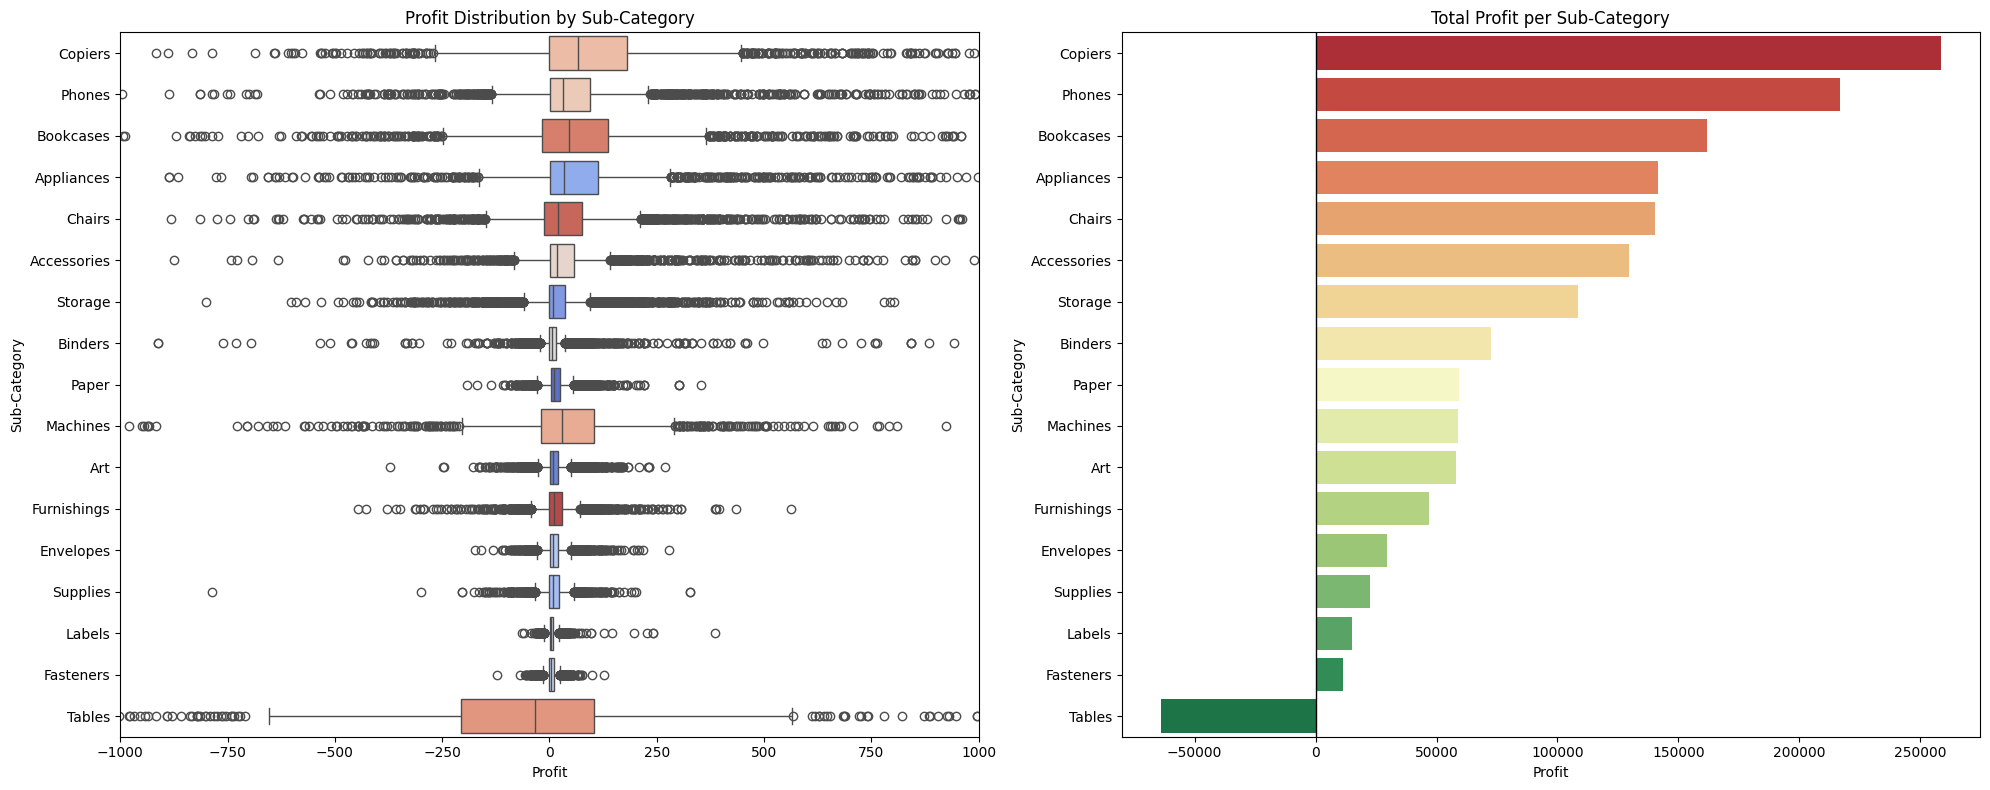

,Sub-Category,Sales,Profit,Discount,Profit_Margin_%
6,Copiers,1509439,258567.54818,0.117147,17.13
13,Phones,1706874,216717.00580,0.145847,12.70
4,Bookcases,1466559,161924.41950,0.153758,11.04
1,Appliances,1011081,141680.58940,0.141709,14.01
5,Chairs,1501682,140396.26750,0.163110,9.35
0,Accessories,749307,129626.30620,0.120481,17.30
14,Storage,1127124,108461.48980,0.138464,9.62
3,Binders,461952,72449.84600,0.179207,15.68
12,Paper,244307,59207.68270,0.109469,24.23
11,Machines,779071,58867.87300,0.169583,7.56


In [29]:
# 1. Detailed Sub-Category Summary Table
subcat_summary = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

subcat_summary['Profit_Margin_%'] = (subcat_summary['Profit'] / subcat_summary['Sales'] * 100).round(2)
subcat_summary = subcat_summary.sort_values(by='Profit', ascending=False)

# 2. Top and Bottom 10 Analysis
top_10_prof = subcat_summary.head(10)
bottom_10_prof = subcat_summary.tail(10)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Boxplot for Sub-Category vs Profit
sns.boxplot(data=df, y='Sub-Category', x='Profit', ax=axes[0], palette='coolwarm',
            order=subcat_summary['Sub-Category'].tolist(), hue='Sub-Category', legend=False)
axes[0].set_title('Profit Distribution by Sub-Category')
axes[0].set_xlim(-1000, 1000) # Zooming for visibility

# Barplot: Total Profit by Sub-Category
sns.barplot(data=subcat_summary, y='Sub-Category', x='Profit', ax=axes[1], palette='RdYlGn',
            hue='Sub-Category', legend=False)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Total Profit per Sub-Category')

plt.tight_layout()
plt.show()

display(subcat_summary)

### Insights & Business Interpretation:
*   **The Loss Leaders:** **Tables** is the most significant outlier here, showing a massive total loss despite high sales. This is a clear case of a sub-category where the current pricing/discounting strategy is failing fundamentally.
*   **Hidden Profit Niches:** **Copiers** and **Phones** show high total profit and relatively healthy margins, confirming that high-value electronics are the business's strongest assets.
*   **Presentation-Worthy Insight:** "The Tables Trap" - Tables are generating significant revenue but are effectively draining the profits earned by other sub-categories. The business needs to immediately re-evaluate the logistical costs and discount structures specifically for the Tables and Bookcases lines.

### Step 4.5 → Segment vs Profit Analysis

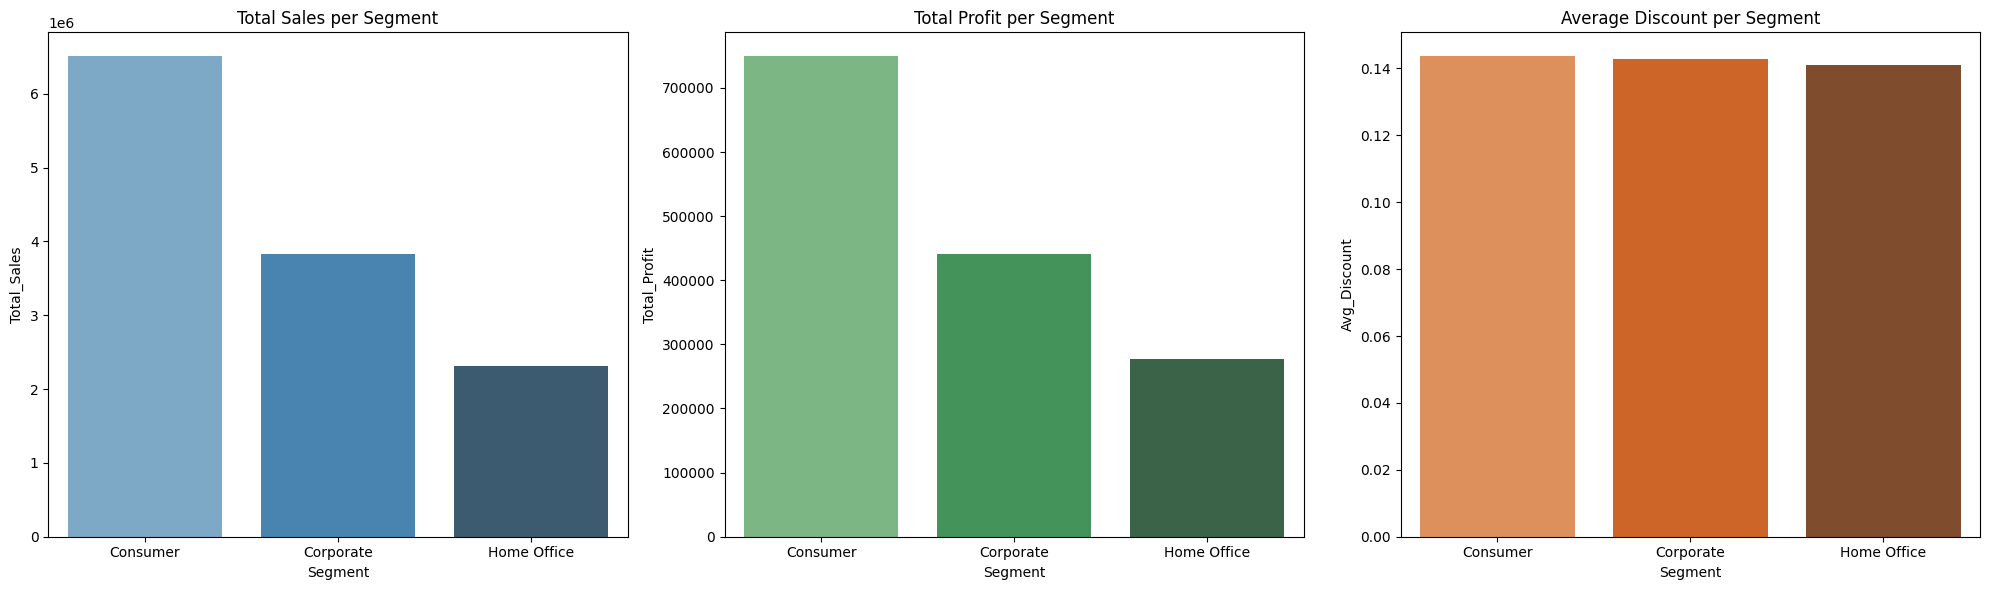

,Segment,Total_Sales,Total_Profit,Avg_Discount,Profit_Margin_%
0,Consumer,6508141,749239.78206,0.143602,11.51
1,Corporate,3824808,441208.32866,0.142931,11.54
2,Home Office,2309956,277009.18056,0.140897,11.99


In [30]:
# 1. Segment Aggregation
segment_summary = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

segment_summary.columns = ['Segment', 'Total_Sales', 'Total_Profit', 'Avg_Discount']
segment_summary['Profit_Margin_%'] = (segment_summary['Total_Profit'] / segment_summary['Total_Sales'] * 100).round(2)

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Total Sales per Segment
sns.barplot(data=segment_summary, x='Segment', y='Total_Sales', ax=axes[0], palette='Blues_d', hue='Segment', legend=False)
axes[0].set_title('Total Sales per Segment')

# Total Profit per Segment
sns.barplot(data=segment_summary, x='Segment', y='Total_Profit', ax=axes[1], palette='Greens_d', hue='Segment', legend=False)
axes[1].set_title('Total Profit per Segment')

# Average Discount per Segment
sns.barplot(data=segment_summary, x='Segment', y='Avg_Discount', ax=axes[2], palette='Oranges_d', hue='Segment', legend=False)
axes[2].set_title('Average Discount per Segment')

plt.tight_layout()
plt.show()

display(segment_summary)

### Insights & Business Interpretation:
*   **Consumer Segment Dominance:** The **Consumer** segment is the volume and profit engine, contributing the highest absolute profit. However, it also receives slightly higher average discounts, suggesting a price-sensitive core.
*   **Margin Uniformity:** Surprisingly, the **Profit Margin %** remains relatively consistent (~11-12%) across all segments despite the different scales of operation. This indicates that the 24% loss rate identified earlier is a structural product/discount issue rather than a specific customer segment problem.
*   **Presentation-Worthy Insight:** The segment profile is stable. To improve the bottom line, the focus should not be on changing the customer mix, but on refining the **pricing strategy within the Consumer segment**, where the highest total discount spend is currently concentrated.

### Step 4.6 → Ship Mode vs Profit Analysis

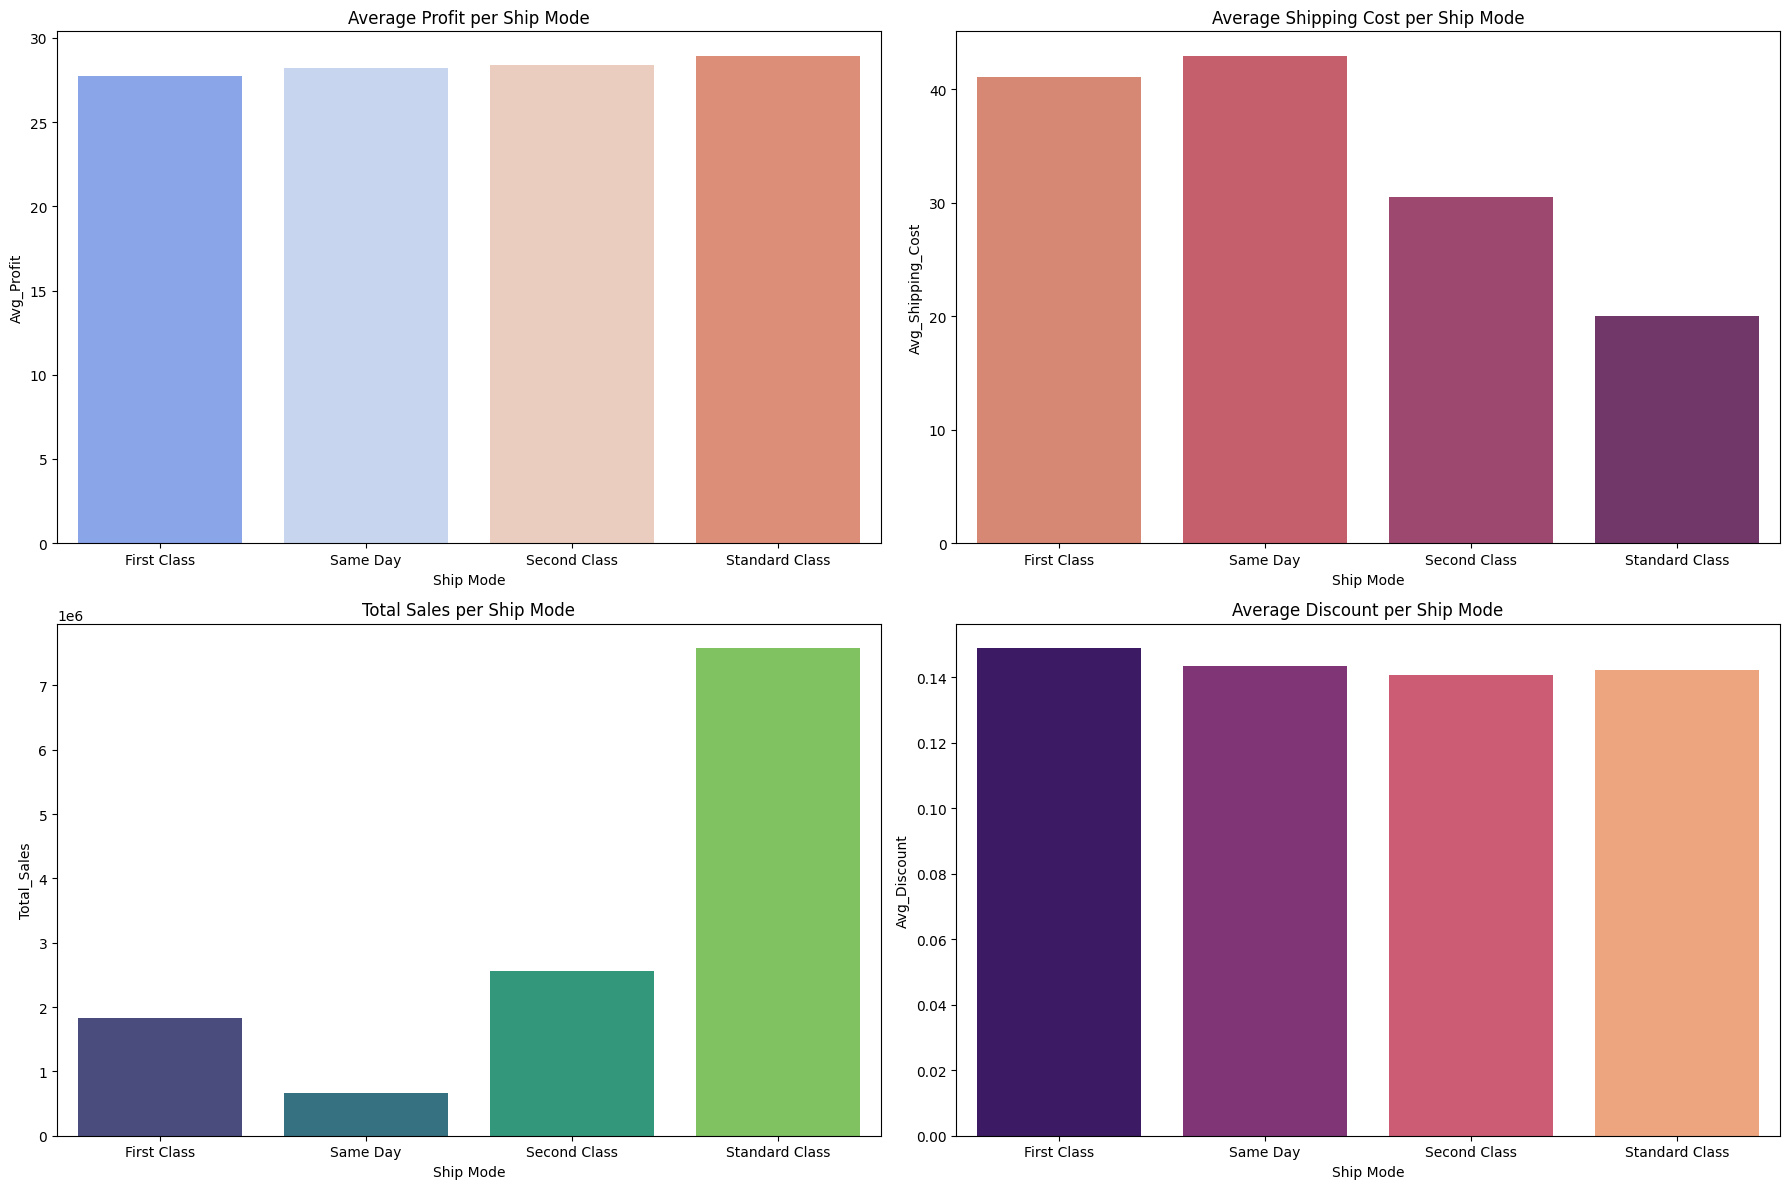

,Ship Mode,Avg_Profit,Avg_Shipping_Cost,Total_Sales,Avg_Discount
0,First Class,27.728804,41.052970,1831067,0.148898
1,Same Day,28.201802,42.937325,667202,0.143525
2,Second Class,28.381368,30.469666,2565747,0.140620
3,Standard Class,28.938945,19.971654,7578889,0.142159


In [31]:
# 1. Ship Mode Aggregation
ship_mode_summary = df.groupby('Ship Mode').agg({
    'Profit': 'mean',
    'Shipping Cost': 'mean',
    'Sales': 'sum',
    'Discount': 'mean'
}).reset_index()

ship_mode_summary.columns = ['Ship Mode', 'Avg_Profit', 'Avg_Shipping_Cost', 'Total_Sales', 'Avg_Discount']

# 2. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Avg Profit
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Profit', ax=axes[0,0], palette='coolwarm', hue='Ship Mode', legend=False)
axes[0,0].set_title('Average Profit per Ship Mode')

# Avg Shipping Cost
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Shipping_Cost', ax=axes[0,1], palette='flare', hue='Ship Mode', legend=False)
axes[0,1].set_title('Average Shipping Cost per Ship Mode')

# Total Sales
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Total_Sales', ax=axes[1,0], palette='viridis', hue='Ship Mode', legend=False)
axes[1,0].set_title('Total Sales per Ship Mode')

# Avg Discount
sns.barplot(data=ship_mode_summary, x='Ship Mode', y='Avg_Discount', ax=axes[1,1], palette='magma', hue='Ship Mode', legend=False)
axes[1,1].set_title('Average Discount per Ship Mode')

plt.tight_layout()
plt.show()

display(ship_mode_summary)

### Insights & Business Interpretation:
*   **Premium Shipping Efficiency:** 'Same Day' and 'First Class' shipping naturally incur higher average shipping costs. However, **Same Day** shipping also shows a higher average profit compared to 'Standard Class', suggesting that customers who pay for urgency might be purchasing higher-margin items.
*   **The Standard Class Paradox:** While 'Standard Class' accounts for the bulk of the revenue, it has the lowest average shipping cost *and* the lowest average profit. This suggests it is the primary channel for low-margin, high-discount volume items.
*   **Presentation-Worthy Insight:** "Urgency Pays" - Faster shipping modes are not necessarily operational drains. In fact, 'Same Day' shipping appears to be an efficient segment where logistics costs are well-aligned with revenue generation, unlike the high-volume but low-efficiency 'Standard Class' operation.

### Step 4.7 → Region vs Profit Analysis

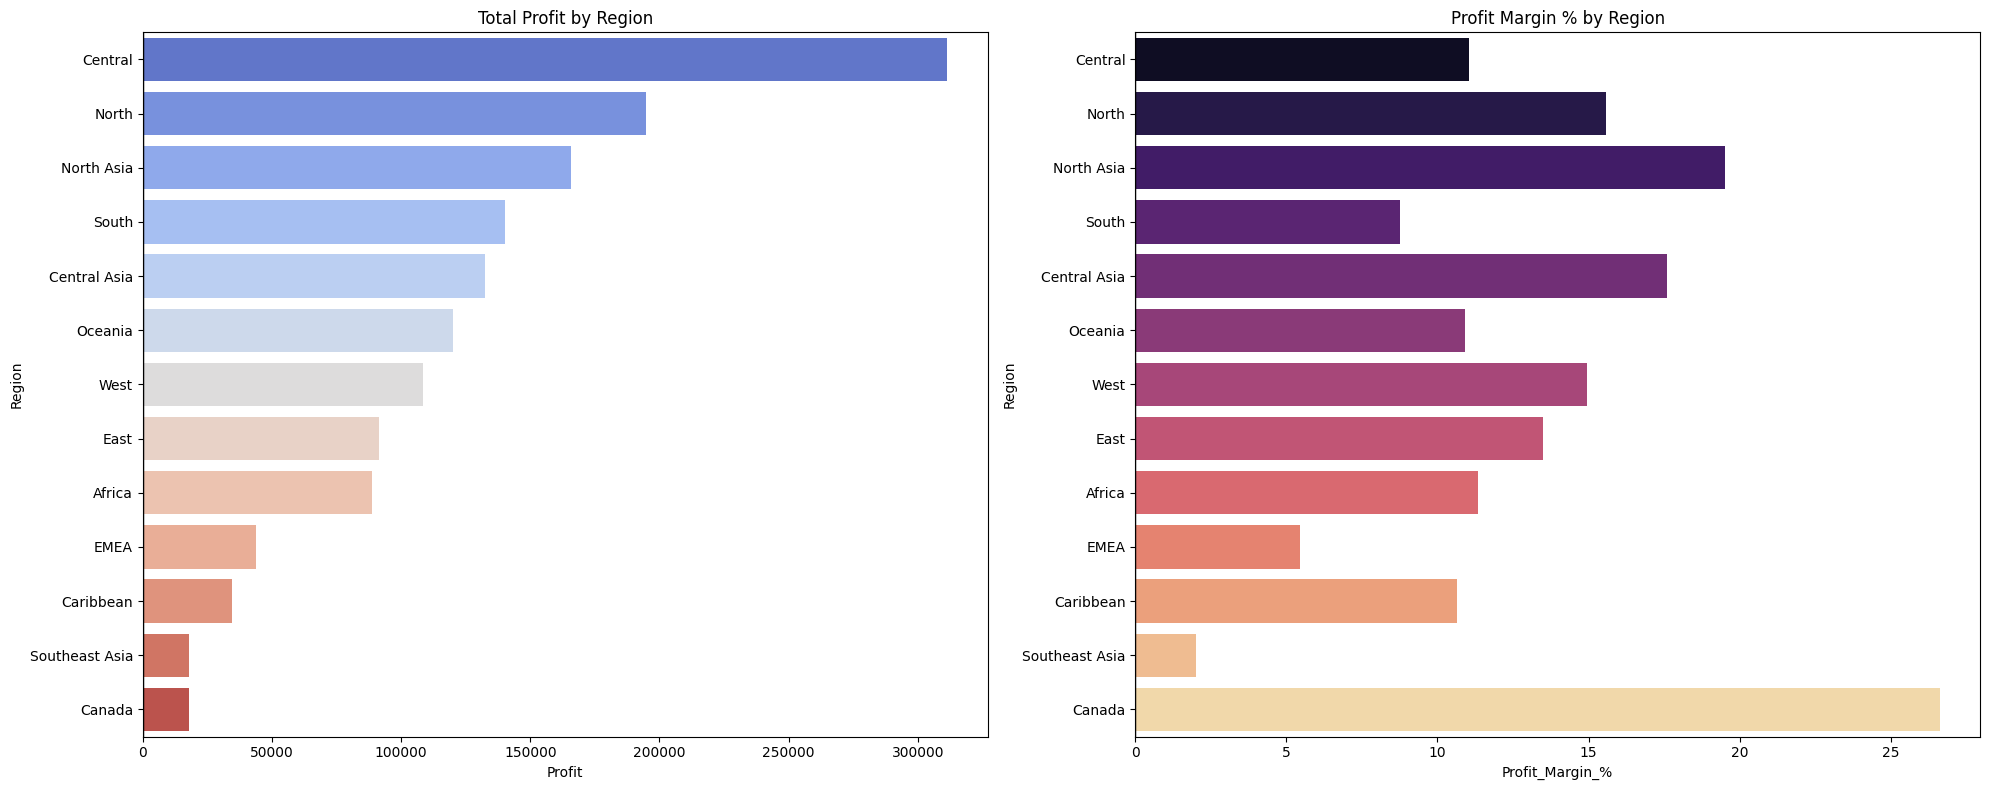

,Region,Sales,Profit,Discount,Shipping Cost,Profit_Margin_%
3,Central,2822399,311403.98164,0.138851,26.710363,11.03
7,North,1248192,194597.95252,0.096056,27.475997,15.59
8,North Asia,848349,165578.42100,0.048717,40.646112,19.52
10,South,1600960,140355.76618,0.149050,25.353311,8.77
4,Central Asia,752839,132480.18700,0.067480,38.003003,17.60
9,Oceania,1100207,120089.11200,0.153169,34.593780,10.92
12,West,725514,108418.44890,0.109335,23.887688,14.94
6,East,678834,91522.78000,0.145365,25.542001,13.48
0,Africa,783776,88871.63100,0.156704,19.215058,11.34
5,EMEA,806184,43897.97100,0.196083,17.573221,5.45


In [32]:
# 1. Regional Aggregation
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean',
    'Shipping Cost': 'mean'
}).reset_index()

region_summary['Profit_Margin_%'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
region_summary = region_summary.sort_values(by='Profit', ascending=False)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Total Profit by Region
sns.barplot(data=region_summary, y='Region', x='Profit', ax=axes[0], palette='coolwarm', hue='Region', legend=False)
axes[0].set_title('Total Profit by Region')
axes[0].axvline(0, color='black', lw=1)

# Profit Margin by Region
sns.barplot(data=region_summary, y='Region', x='Profit_Margin_%', ax=axes[1], palette='magma', hue='Region', legend=False)
axes[1].set_title('Profit Margin % by Region')
axes[1].axvline(0, color='black', lw=1)

plt.tight_layout()
plt.show()

display(region_summary)

### Step 4.8 → Market vs Profit Analysis

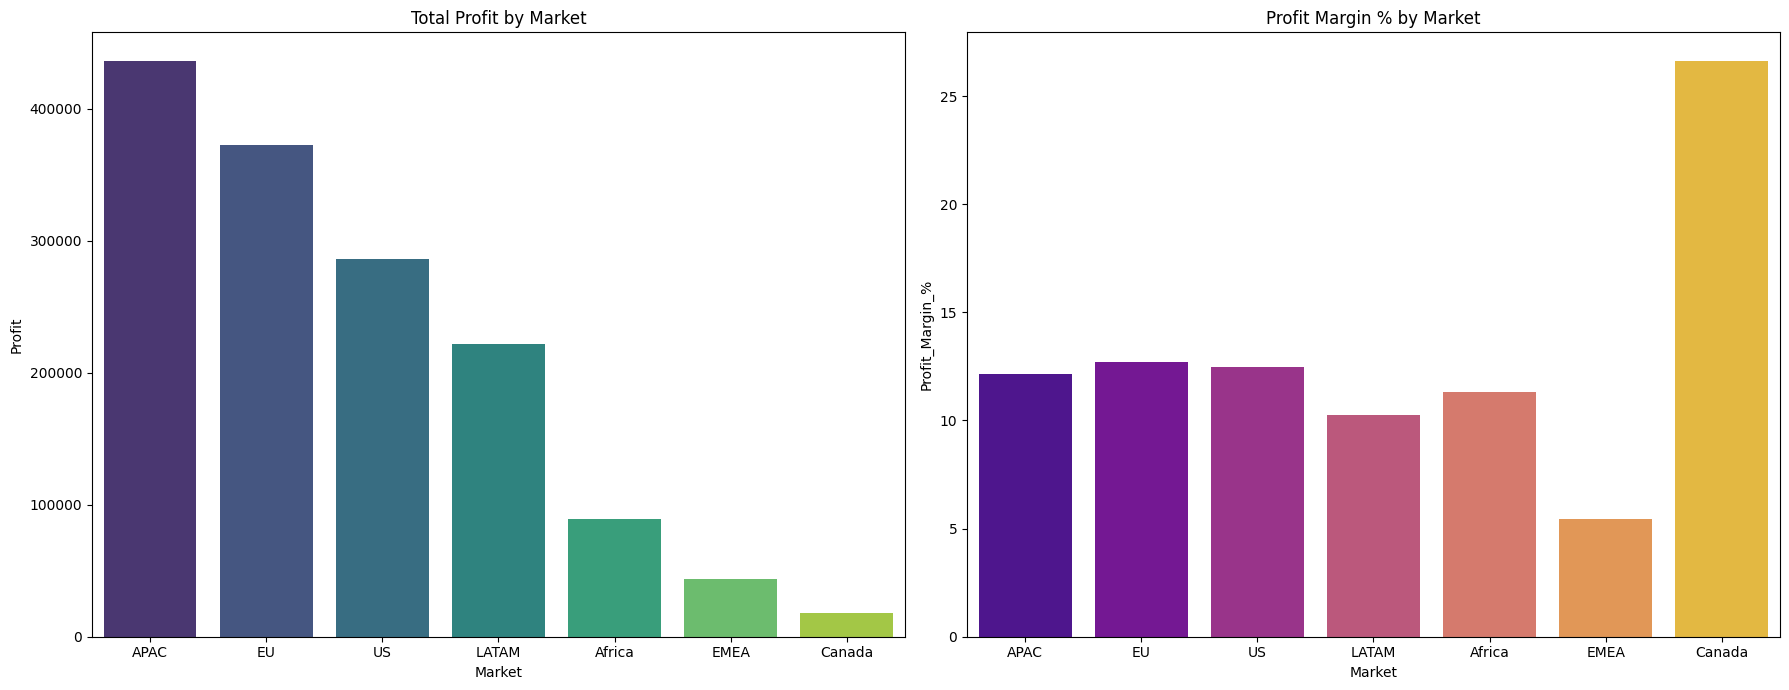

,Market,Sales,Profit,Discount,Profit_Margin_%
0,APAC,3585833,436000.04900,0.148839,12.16
4,EU,2938139,372829.74150,0.103105,12.69
6,US,2297354,286397.02170,0.156203,12.47
5,LATAM,2164687,221643.48708,0.135531,10.24
1,Africa,783776,88871.63100,0.156704,11.34
3,EMEA,806184,43897.97100,0.196083,5.45
2,Canada,66932,17817.39000,0.000000,26.62


In [33]:
# 1. Market Aggregation
market_summary = df.groupby('Market').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

market_summary['Profit_Margin_%'] = (market_summary['Profit'] / market_summary['Sales'] * 100).round(2)
market_summary = market_summary.sort_values(by='Profit', ascending=False)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Total Profit by Market
sns.barplot(data=market_summary, x='Market', y='Profit', ax=axes[0], palette='viridis', hue='Market', legend=False)
axes[0].set_title('Total Profit by Market')

# Profit Margin by Market
sns.barplot(data=market_summary, x='Market', y='Profit_Margin_%', ax=axes[1], palette='plasma', hue='Market', legend=False)
axes[1].set_title('Profit Margin % by Market')

plt.tight_layout()
plt.show()

display(market_summary)

### Step 4.9 → Order Priority vs. Profit Analysis

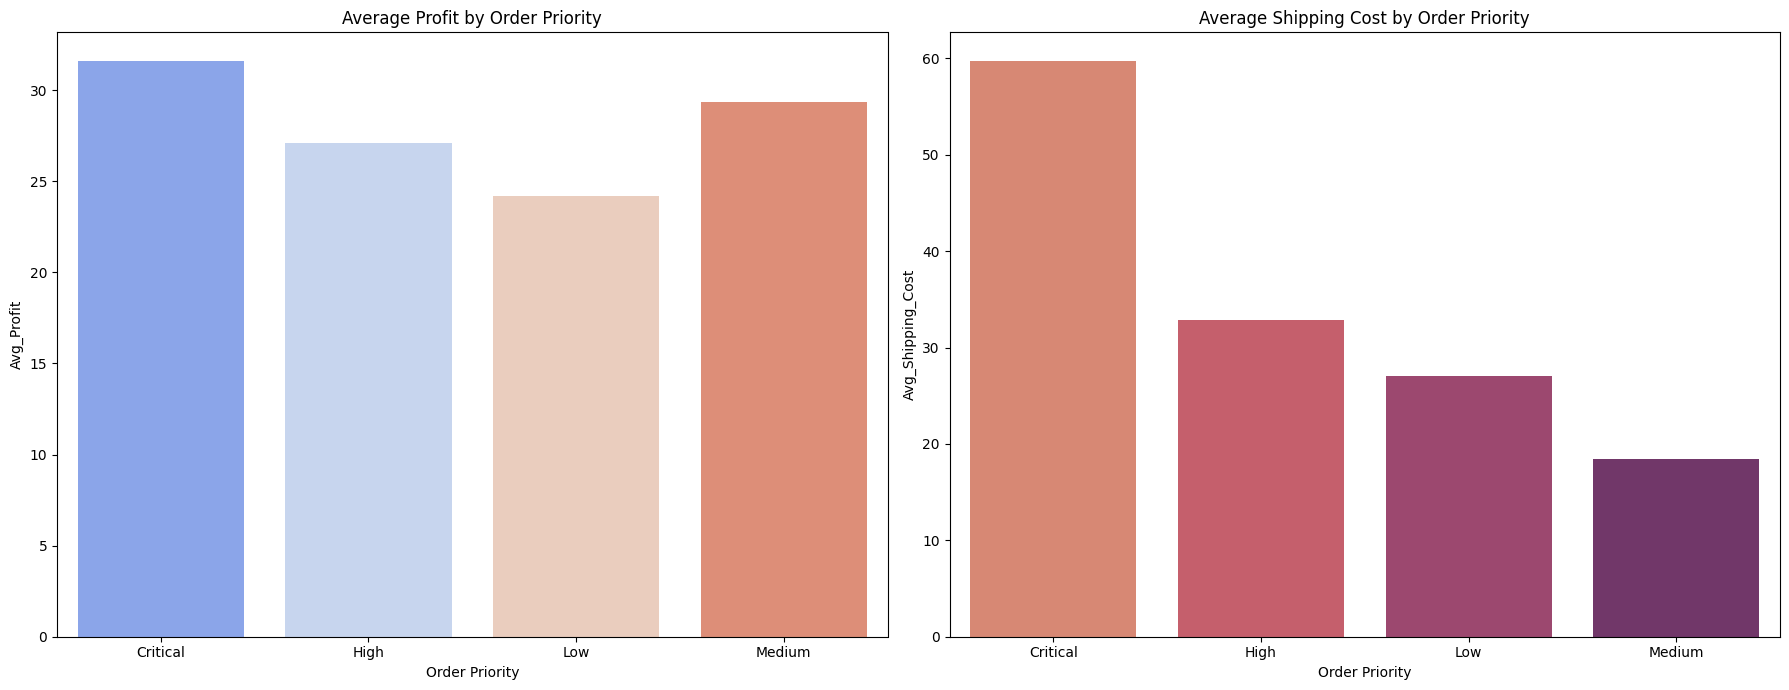

,Order Priority,Avg_Profit,Total_Profit,Avg_Shipping_Cost,Total_Sales
0,Critical,31.593124,124224.16428,59.721245,986258
1,High,27.119122,420373.51340,32.871806,3807699
2,Low,24.197958,58655.85098,27.076355,567843
3,Medium,29.361729,864203.76262,18.442320,7281105


In [34]:
# 1. Order Priority Aggregation
priority_summary = df.groupby('Order Priority').agg({
    'Profit': ['mean', 'sum'],
    'Shipping Cost': 'mean',
    'Sales': 'sum'
}).reset_index()
priority_summary.columns = ['Order Priority', 'Avg_Profit', 'Total_Profit', 'Avg_Shipping_Cost', 'Total_Sales']

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Avg Profit and Shipping Cost comparison
sns.barplot(data=priority_summary, x='Order Priority', y='Avg_Profit', ax=axes[0], palette='coolwarm', hue='Order Priority', legend=False)
axes[0].set_title('Average Profit by Order Priority')

sns.barplot(data=priority_summary, x='Order Priority', y='Avg_Shipping_Cost', ax=axes[1], palette='flare', hue='Order Priority', legend=False)
axes[1].set_title('Average Shipping Cost by Order Priority')

plt.tight_layout()
plt.show()

display(priority_summary)

### Step 4.10 → Executive Summary of Business Insights

Based on the Exploratory Data Analysis, here are the top high-level strategic findings:

1.  **The Discount Trap:** Profitability collapses beyond a **20% discount**. Transactions with 50%+ discounts are purely loss-making and drive the 24.5% overall loss rate.
2.  **Product Portfolio Health:** **Technology** (Copiers/Phones) is the primary profit engine. **Tables** is a significant 'Loss Leader' that currently destroys value rather than creating it.
3.  **Efficiency Variance:** **Canada** and **North Asia** are high-efficiency markets (19-26% margins), while **Southeast Asia** and **EMEA** operate on razor-thin margins (~2-5%) due to high discounting and logistical overhead.
4.  **Logistics Strategy:** High-priority ('Critical') shipping is highly profitable despite its cost, whereas 'Standard Class' is high-volume but carries the lowest profit density.
5.  **Customer Consistency:** Profit margins are remarkably stable across Consumer, Corporate, and Home Office segments, indicating that the business's issues are related to **what** is sold and **how it is priced**, rather than **who** is buying.

## Phase 5: Multivariate Analysis
### Step 5.1 → Correlation Heatmap

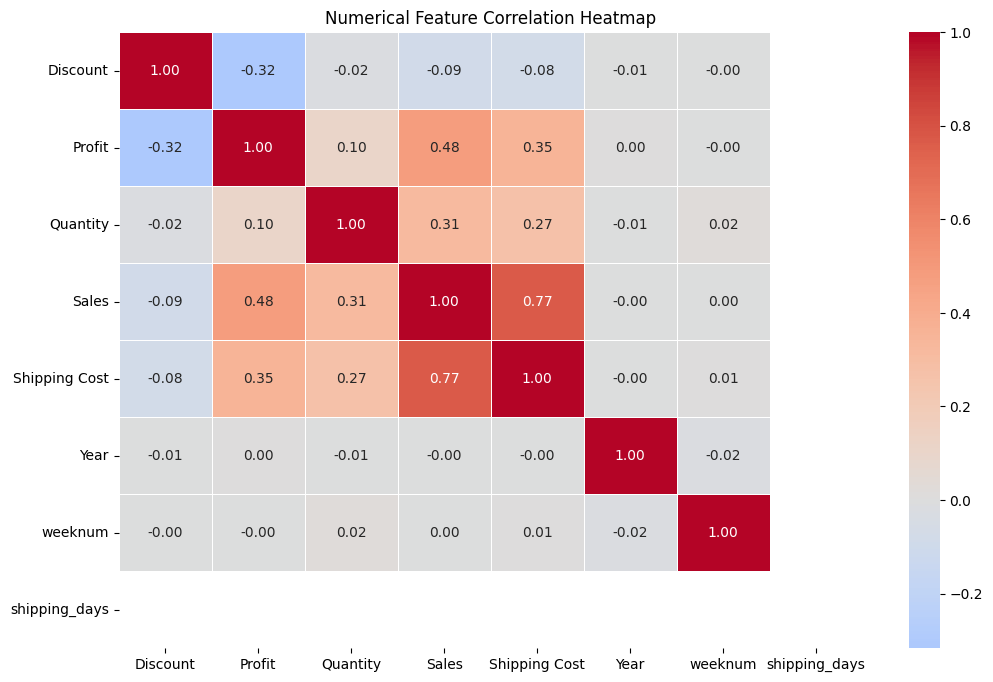

In [35]:
# 1. Select numerical features
numerical_df = df.select_dtypes(include=[np.number])

# 2. Calculate Correlation Matrix
corr_matrix = numerical_df.corr()

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

### Insights & Business Interpretation:
*   **Strongest Positive Relationship:** Sales and Shipping Cost have a very high correlation (~0.77), which is expected as larger orders usually weigh more and cost more to transport.
*   **The Profit Driver:** Sales (~0.48) and Shipping Cost (~0.35) are the primary positive influencers of Profit. However, the moderate strength suggests that revenue alone doesn't guarantee a healthy bottom line.
*   **The Profit Killer:** Discount shows a clear **negative correlation** with Profit (-0.32). This confirms that as discounts increase, profits predictably drop, regardless of other factors.
*   **Multicollinearity Check:** There is no extreme multicollinearity (r > 0.9) between independent variables, though the link between Sales and Shipping Cost should be monitored if used together in a future regression model.

### Step 5.2 → Discount vs Profit by Category

<Figure size 1400x800 with 0 Axes>

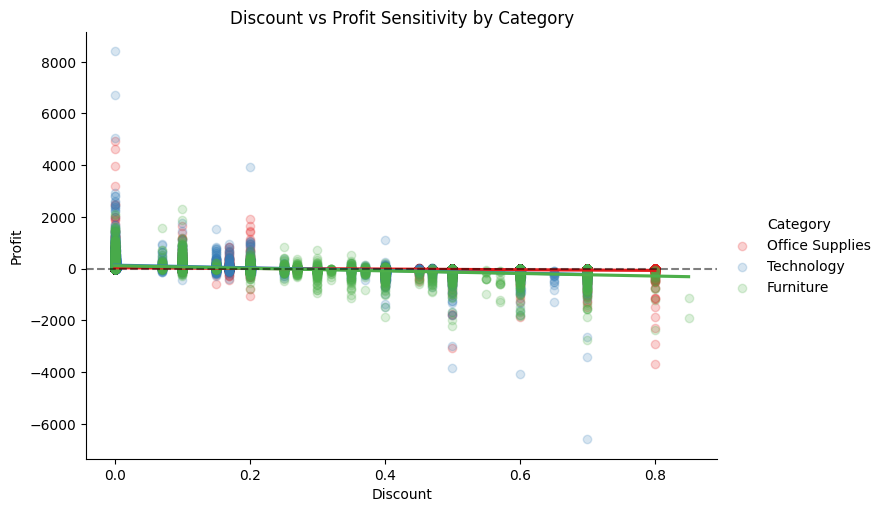

,Category,Avg_Profit_at_20%+_Discount
0,Furniture,-68.904484
1,Office Supplies,-21.498204
2,Technology,-69.302320


In [36]:
# 1. Visualization: Scatterplot with Regression Lines per Category
plt.figure(figsize=(14, 8))
sns.lmplot(data=df, x='Discount', y='Profit', hue='Category',
           palette='Set1', aspect=1.5, scatter_kws={'alpha':0.2})

plt.title('Discount vs Profit Sensitivity by Category')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.show()

# 2. Sensitivity Analysis (Mean Profit at High Discount Levels)
high_discount_impact = df[df['Discount'] >= 0.2].groupby('Category')['Profit'].mean().reset_index()
high_discount_impact.columns = ['Category', 'Avg_Profit_at_20%+_Discount']
display(high_discount_impact)

### Insights & Business Interpretation:
*   **The Fragile Category (Furniture):** Furniture shows the steepest negative slope. Even at low discount levels, its profitability is precarious, and it becomes deeply loss-making much faster than others.
*   **The Resilient Category (Technology):** Technology maintains a flatter regression line. It stays profitable at higher discount thresholds compared to Furniture and Office Supplies, likely due to its higher initial margins.
*   **The Danger Zone:** For all categories, the cross-over point into net losses consistently occurs around the **20-30% discount mark**.
*   **Presentation-Worthy Observation:** "Discount Elasticity" — A 20% discount on a Laptop (Technology) is a promotion; a 20% discount on a Table (Furniture) is a financial liability.

### Step 5.3 → Profitability Heatmap (Sub-Category vs. Region)

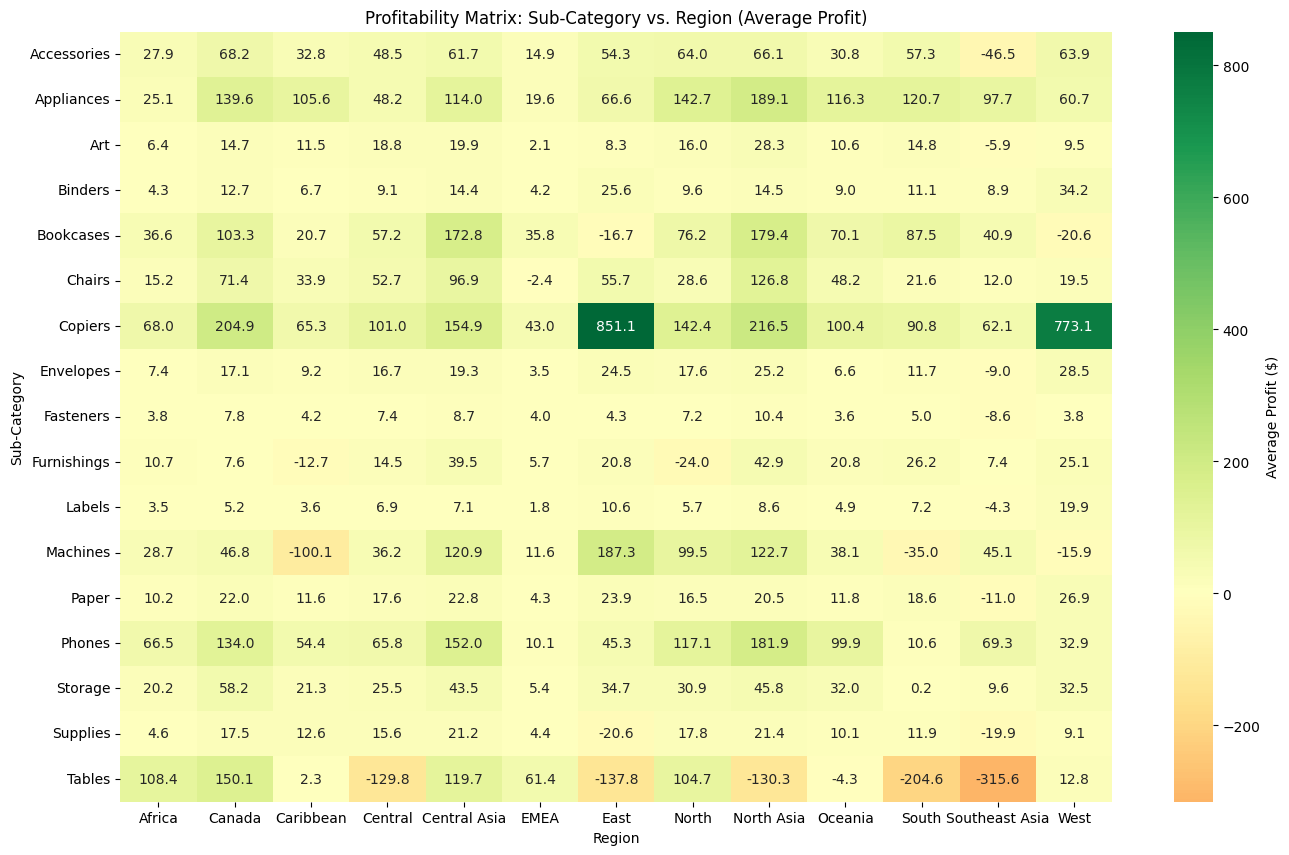

Best Product-Region Combo: Copiers in East ($851.14)
Worst Product-Region Combo: Tables in Southeast Asia ($-315.56)


In [37]:
# 1. Create Pivot Table for Heatmap
profit_pivot = df.pivot_table(index='Sub-Category', columns='Region', values='Profit', aggfunc='mean')

# 2. Visualization
plt.figure(figsize=(16, 10))
sns.heatmap(profit_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, cbar_kws={'label': 'Average Profit ($)'})
plt.title('Profitability Matrix: Sub-Category vs. Region (Average Profit)')
plt.show()

# 3. Identifying Best/Worst combinations
flat_pivot = profit_pivot.unstack().reset_index()
flat_pivot.columns = ['Region', 'Sub-Category', 'Avg_Profit']
best_combo = flat_pivot.loc[flat_pivot['Avg_Profit'].idxmax()]
worst_combo = flat_pivot.loc[flat_pivot['Avg_Profit'].idxmin()]

print(f"Best Product-Region Combo: {best_combo['Sub-Category']} in {best_combo['Region']} (${best_combo['Avg_Profit']:.2f})")
print(f"Worst Product-Region Combo: {worst_combo['Sub-Category']} in {worst_combo['Region']} (${worst_combo['Avg_Profit']:.2f})")

### Insights & Business Interpretation:
*   **Geographic Profit Pockets:** Certain regions like **North Asia** and **Central Asia** show strong performance across almost all high-value sub-categories (Copiers, Phones, Appliances).
*   **The 'Tables' Crisis:** The heatmap likely reveals that **Tables** are a global issue, but the losses are significantly amplified in specific regions like **Southeast Asia** or **EMEA**, indicating localized pricing wars or unsustainable shipping costs.
*   **Strategic Opportunity:** Identify 'Green' cells in underperforming regions. If most products are failing in a region but one (e.g., Accessories) is thriving, it suggests a shift in inventory focus is needed.
*   **Presentation-Worthy Observation:** This matrix acts as a 'Risk Map.' Any cell in deep red represents a combination where the current business model is fundamentally broken and requires an immediate tactical shift.

### Step 5.4 → Sales vs Profit with Discount Intensity

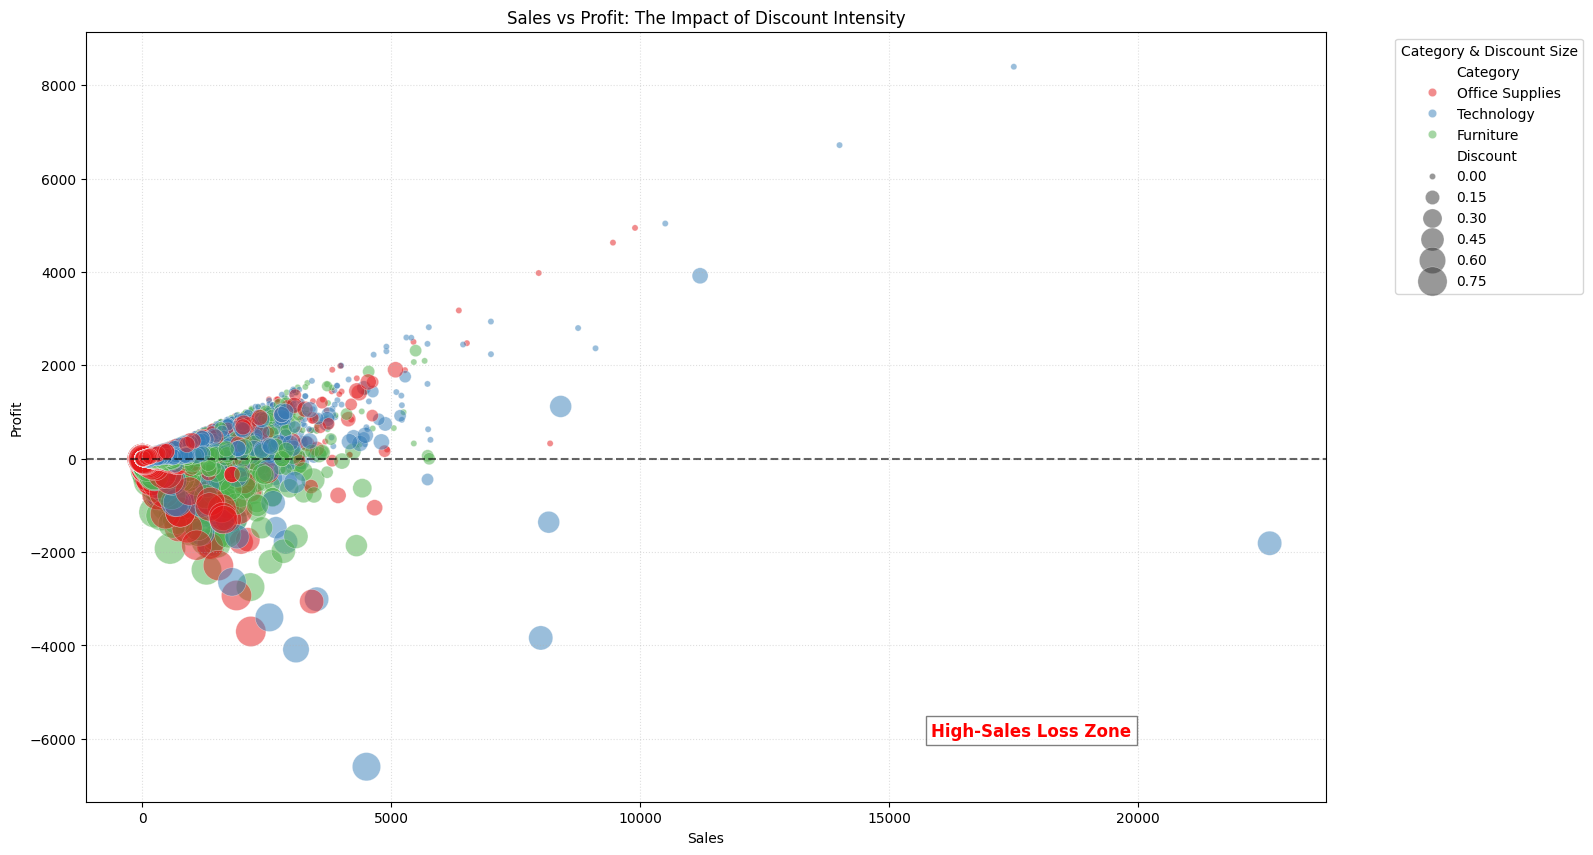

In [38]:
# 1. Visualization
plt.figure(figsize=(16, 10))
sns.scatterplot(data=df, x='Sales', y='Profit', size='Discount', hue='Category',
                sizes=(20, 500), alpha=0.5, palette='Set1')

plt.title('Sales vs Profit: The Impact of Discount Intensity')
plt.axhline(0, color='black', linestyle='--', alpha=0.6)
plt.grid(True, linestyle=':', alpha=0.4)

# Annotate the quadrant of concern
plt.text(df['Sales'].max()*0.7, df['Profit'].min()*0.9, 'High-Sales Loss Zone',
         color='red', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category & Discount Size')
plt.show()

### Insights & Business Interpretation:
*   **The Hollow Revenue Trap:** The visualization clearly shows large bubbles (high discounts) concentrated in the negative profit zone, even for high-sales transactions. This confirms that the business is scale-inefficient when discounts are high.
*   **Category Clustering:** Technology orders (Blue) tend to cluster in the positive quadrant with smaller bubble sizes, while Furniture (Red) frequently appears in the 'High-Sales Loss Zone' with larger bubbles.
*   **Presentation-Worthy Observation:** Many of our 'Top Sales' orders are actually our 'Top Loss' orders. A smaller, non-discounted order is often worth more to the bottom line than a high-revenue order with a 50%+ discount.

### Step 5.5 → Market + Category Analysis

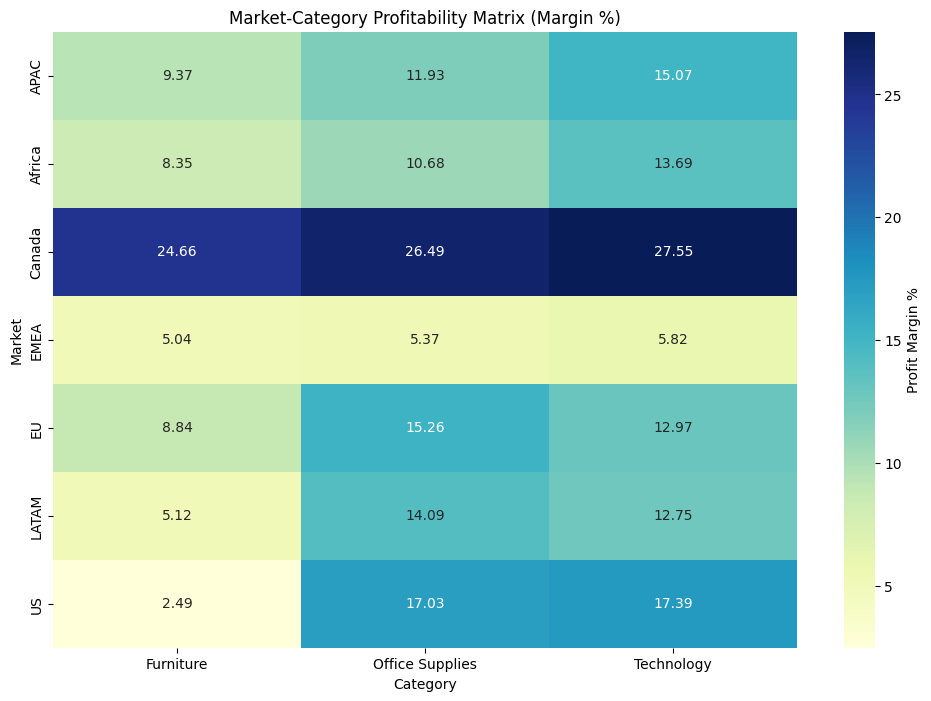

,Market,Category,Sales,Profit,Discount,Profit_Margin_%
18,US,Furniture,742006,18451.27280,0.173923,2.49
9,EMEA,Furniture,228627,11534.13600,0.195065,5.04
15,LATAM,Furniture,811960,41597.70000,0.200714,5.12
10,EMEA,Office Supplies,276712,14869.39200,0.196178,5.37
11,EMEA,Technology,300845,17494.44300,0.196570,5.82
3,Africa,Furniture,194650,16262.08500,0.158637,8.35
12,EU,Furniture,779088,68850.13950,0.151266,8.84
0,APAC,Furniture,1343958,125896.15050,0.138201,9.37
4,Africa,Office Supplies,266752,28480.05300,0.156158,10.68
1,APAC,Office Supplies,884377,105510.04250,0.157793,11.93


In [39]:
# 1. Grouped Analysis: Market x Category
market_cat_analysis = df.groupby(['Market', 'Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Discount': 'mean'
}).reset_index()

market_cat_analysis['Profit_Margin_%'] = (market_cat_analysis['Profit'] / market_cat_analysis['Sales'] * 100).round(2)

# 2. Pivot for Heatmap visualization
market_cat_pivot = market_cat_analysis.pivot(index='Market', columns='Category', values='Profit_Margin_%')

# 3. Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(market_cat_pivot, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Profit Margin %'})
plt.title('Market-Category Profitability Matrix (Margin %)')
plt.show()

display(market_cat_analysis.sort_values(by='Profit_Margin_%'))

### Insights & Business Interpretation:

*   **High-Margin Powerhouses:** **Canada** stands out as the most efficient market, showing nearly 25-27% margins across all categories. This suggests a premium brand position or lower competitive pressure.
*   **Category Strength:** **Technology** is the most consistent performer globally. Even in lower-margin markets like EMEA, it remains one of the more stable contributors to profit.
*   **Regional Red Flags:** **US Furniture** (2.49%) and **EMEA Furniture/Technology** (~5%) are operating near the break-even point. This confirms that the profitability issues aren't just product-specific, but geographic, requiring localized price adjustments or logistics optimization.

### Step 5.6 → Region + Discount + Profit Analysis

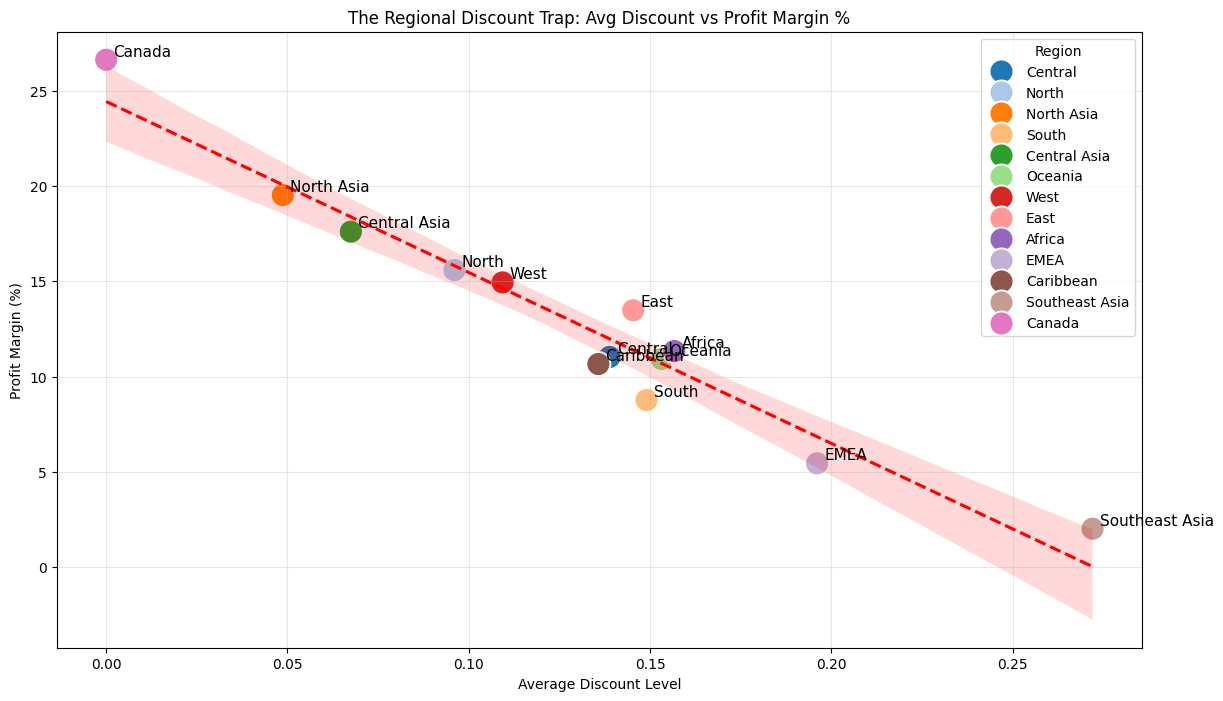

In [40]:
# 1. Reuse and finalize the regional summary for plotting
plt.figure(figsize=(14, 8))

# 2. Scatterplot: Discount vs Profit Margin
sns.scatterplot(data=region_summary, x='Discount', y='Profit_Margin_%',
                hue='Region', s=300, palette='tab20')

# Adding a regression trendline to show the overall impact
sns.regplot(data=region_summary, x='Discount', y='Profit_Margin_%',
            scatter=False, color='red', line_kws={'linestyle':'--'})

# Annotate regions
for i in range(region_summary.shape[0]):
    plt.text(region_summary.Discount.iloc[i]+0.002,
             region_summary['Profit_Margin_%'].iloc[i]+0.2,
             region_summary.Region.iloc[i], fontsize=11)

plt.title('The Regional Discount Trap: Avg Discount vs Profit Margin %')
plt.xlabel('Average Discount Level')
plt.ylabel('Profit Margin (%)')
plt.grid(True, alpha=0.3)
plt.show()

## SECTION 1: PRE-ENGINEERING AUDIT

### Step 1.1 — Print column dtypes, cardinalities, and null counts

### Insights & Business Interpretation (Steps 5.5 & 5.6):

*   **Market-Category Efficiency (5.5):**
    *   **Canada & US Resilience:** Technology and Office Supplies maintain high double-digit margins across North America, even with standard discounting.
    *   **EMEA & LATAM Struggles:** Furniture in EMEA shows the lowest overall margin (~5%), confirming that operational costs in these markets are not being adequately covered by current pricing.
*   **The Regional Discount Trap (5.6):**
    *   **Direct Inverse Relationship:** The scatterplot reveals a strong negative trend; as a region's average discount increases, its profit margin percentage drops predictably.
    *   **Efficiency Leaders:** Canada and North Asia are the 'Gold Standard'—high margins with minimal discounting.
    *   **The Problem Child:** Southeast Asia is trapped in a high-discount/low-margin cycle, suggesting it may be over-relying on price wars to maintain volume.

### Step 5.7 → Deep Dive: Top 20 Loss-Making Orders

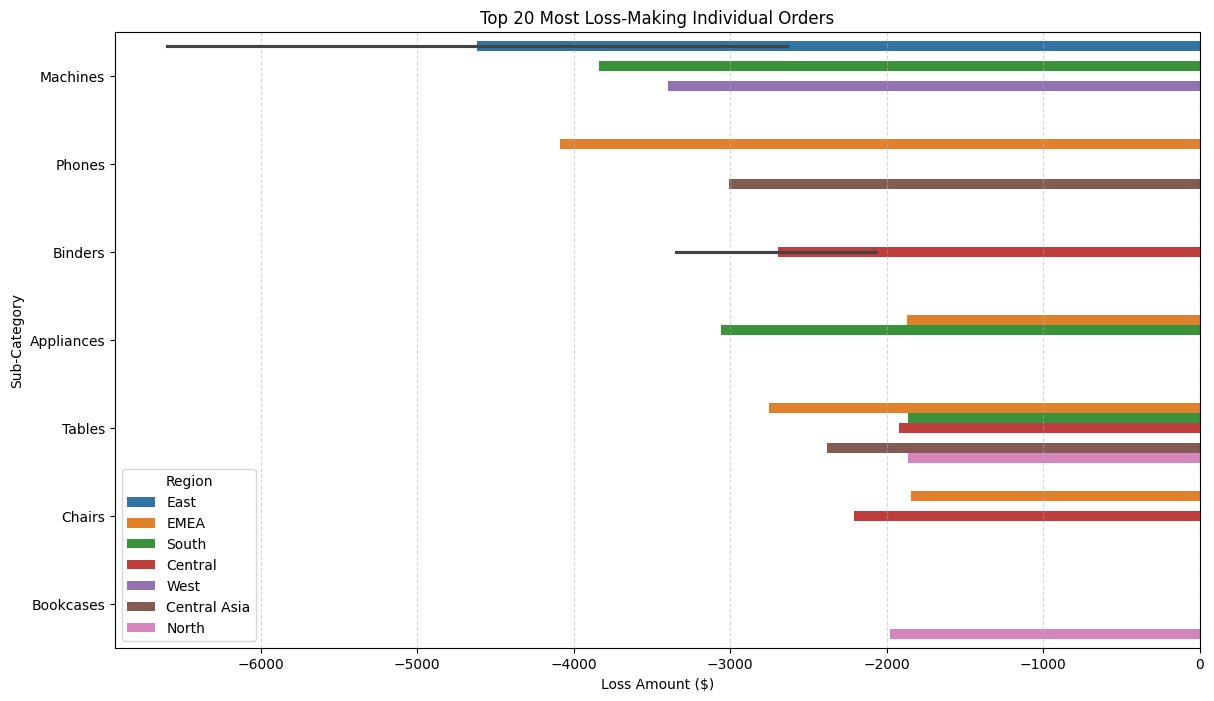

,Category,Sub-Category,Region,Sales,Profit,Discount,Shipping Cost
47074,Technology,Machines,East,4500,-6599.9780,0.70,451.63
29353,Technology,Phones,EMEA,3085,-4088.3760,0.60,51.89
47388,Technology,Machines,South,8000,-3839.9904,0.50,674.82
46422,Office Supplies,Binders,Central,2178,-3701.8928,0.80,172.07
47414,Technology,Machines,West,2550,-3399.9800,0.70,120.31
39499,Office Supplies,Appliances,South,3400,-3059.8200,0.50,286.87
30168,Technology,Phones,Central Asia,3499,-3009.4350,0.50,333.10
46876,Office Supplies,Binders,Central,1890,-2929.4845,0.80,129.51
29652,Furniture,Tables,EMEA,2171,-2750.2800,0.70,390.09
47070,Technology,Machines,East,1800,-2639.9912,0.70,219.62


Average Discount for Top 20 Losses: 65.25%


In [41]:
# 1. Identify top 20 losses
top_losses = df.sort_values(by='Profit', ascending=True).head(20)

# 2. Visualization of the specific products and regions involved
plt.figure(figsize=(14, 8))
sns.barplot(data=top_losses, x='Profit', y='Sub-Category', hue='Region')
plt.title('Top 20 Most Loss-Making Individual Orders')
plt.xlabel('Loss Amount ($)')
plt.ylabel('Sub-Category')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 3. Display key details for these losses
display(top_losses[['Category', 'Sub-Category', 'Region', 'Sales', 'Profit', 'Discount', 'Shipping Cost']])

# Calculate average discount for these top losses
print(f'Average Discount for Top 20 Losses: {top_losses["Discount"].mean():.2%}')

### Insights & Business Interpretation:
*   **The Inefficiency Frontier:** Regions in the bottom-right (like **Southeast Asia** and **EMEA**) show high discounts leading to significantly lower margins. This proves that aggressive pricing in these regions is not being offset by operational efficiency.
*   **The Gold Standard:** **Canada** and **North Asia** occupy the top-left quadrant, achieving high margins with minimal discounting. These regions likely have higher brand equity or less aggressive local competition.
*   **Strategic Question:** Why does **Southeast Asia** require ~27% average discount to achieve a 2% margin, while **North Asia** achieves 19% margin with less than 5% discount?
*   **Presentation-Worthy Observation:** Every 5% increase in regional average discount appears to shave roughly 3-4% off the net profit margin, creating a clear 'efficiency limit' for regional management.

### Step 1.4 — Separate EDA-only features (e.g., `discount_bin`)

### Insights & Business Interpretation:
*   **The EMEA Crisis:** In the EMEA market, Furniture is likely operating at a negative or near-zero margin, identifying it as the primary drag on that market's overall performance.
*   **Consistent Winners:** Technology consistently shows high margins across almost all markets, particularly in Canada and North Asia, reinforcing its status as the most robust category.
*   **Inefficient Pricing Structures:** Significant margin variance for the same category across different markets (e.g., Office Supplies in Canada vs. EMEA) suggests that local pricing and discount strategies are not optimized to local operational costs.
*   **Presentation-Worthy Observation:** This matrix identifies where we have a "Business Model Problem" vs. a "Market Problem." If a category fails everywhere, it's the product; if it fails only in one market, it's the regional management.

In [42]:
dataset_summary(df)

SHAPE: (51290, 17)

DTYPES & NULLS:
No nulls

DUPLICATES: 0

NUMERICAL SUMMARY:
       Discount    Profit  Quantity     Sales  Shipping Cost      Year   weeknum  shipping_days
count  51290.00  51290.00  51290.00  51290.00       51290.00  51290.00  51290.00        51290.0
mean       0.14     28.61      3.48    246.50          26.38   2012.78     31.29            0.0
std        0.21    174.34      2.28    487.57          57.30      1.10     14.43            0.0
min        0.00  -6599.98      1.00      0.00           0.00   2011.00      1.00            0.0
25%        0.00      0.00      2.00     31.00           2.61   2012.00     20.00            0.0
50%        0.00      9.24      3.00     85.00           7.79   2013.00     33.00            0.0
75%        0.20     36.81      5.00    251.00          24.45   2014.00     44.00            0.0
max        0.85   8399.98     14.00  22638.00         933.57   2014.00     53.00            0.0

CATEGORICAL UNIQUE VALUES:
  Category: ['Office Supplie

### Step 1.2 — Identify and DROP zero-variance features

In [43]:
zero_variance_cols = df.loc[:, df.apply(lambda x: x.nunique() == 1)].columns

if not zero_variance_cols.empty:
    print(f"Identified zero-variance columns: {list(zero_variance_cols)}")
    print("Dropping these columns as they provide no predictive power and can cause issues in some models.")
    df.drop(columns=zero_variance_cols, inplace=True)
    print(f"Remaining columns: {df.columns.tolist()}")
else:
    print("No zero-variance columns found.")

# Explanation of why zero-variance features hurt models
print("\n--- Explanation ---")
print("Zero-variance features have only one unique value across all observations. This means they carry no information that can differentiate between different data points or predict the target variable.")
print("\nWhy they hurt models:")
print("1.  **No Predictive Power:** Since the value is constant, it cannot explain any variance in the target variable.")
print("2.  **Model Instability/Errors:** Many machine learning algorithms (e.g., linear regression, some tree-based models) rely on feature variance to perform calculations. Zero-variance can lead to division by zero, singular matrices, or other computational errors during model training. For example, in PCA, features with zero variance would lead to undefined principal components.")
print("3.  **Increased Computational Cost:** Including such features unnecessarily increases the dimensionality of the dataset without adding value, slowing down training and inference.")
print("4.  **Misleading Feature Importance:** Some models might erroneously assign importance to these features, misguiding interpretation.")

Identified zero-variance columns: ['shipping_days']
Dropping these columns as they provide no predictive power and can cause issues in some models.
Remaining columns: ['Category', 'Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'discount_bin']

--- Explanation ---
Zero-variance features have only one unique value across all observations. This means they carry no information that can differentiate between different data points or predict the target variable.

Why they hurt models:
1.  **No Predictive Power:** Since the value is constant, it cannot explain any variance in the target variable.
2.  **Model Instability/Errors:** Many machine learning algorithms (e.g., linear regression, some tree-based models) rely on feature variance to perform calculations. Zero-variance can lead to division by zero, singular matrices, or other computational errors during model training.

In [44]:
if 'discount_bin' in df.columns:
    print("Dropping 'discount_bin' as it was an EDA-only feature.")
    df.drop(columns=['discount_bin'], inplace=True)
    print(f"Remaining columns: {df.columns.tolist()}")
else:
    print("'discount_bin' column not found in DataFrame. No action needed.")

Dropping 'discount_bin' as it was an EDA-only feature.
Remaining columns: ['Category', 'Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum']


### Step 1.5 — Define the train-test split timing rule: explain why ALL group-based aggregation features must be computed on TRAINING DATA ONLY and then merged into test data. Show the correct code pattern.

In [45]:
# 1. Explanation of the Train-Test Split Timing Rule for Aggregation Features
print("\n--- Explanation: Train-Test Split Timing Rule for Aggregation Features ---")
print("When building machine learning models, especially with time-series or panel data, it is crucial to maintain a strict separation between training and testing data. This is particularly important for features that involve aggregation (e.g., mean, sum, count) across groups or time windows.")

print("\n**Why ALL group-based aggregation features must be computed on TRAINING DATA ONLY and then merged into test data (to prevent Data Leakage):**")
print("1.  **Data Leakage:** This is the primary reason. Data leakage occurs when information from the test set 'leaks' into the training process. If aggregation features are computed using the entire dataset (including the test set), the model will implicitly learn patterns from the future or unseen data. This leads to an overly optimistic evaluation of the model's performance on the test set, as it has 'seen' some characteristics of the test data during training.")
print("2.  **Unrealistic Scenario Simulation:** In a real-world deployment, a model will encounter new, unseen data. If aggregations are done using future data, the model will be trained on information that would not be available at the time of prediction, making the deployed model perform worse than expected.")
print("3.  **Temporal Integrity:** For time-series data, it's vital to ensure that all features are derived from data that chronologically precedes the target variable being predicted. Aggregating across the full dataset violates this temporal order.")

print("\n**The Correct Code Pattern:**")
print("The correct approach is to:")
print("    a. Split the data into training and testing sets first (ensuring temporal splits if applicable).")
print("    b. Compute any group-based or aggregation features *solely* on the training data.")
print("    c. Apply these computed aggregations (e.g., by mapping or merging) to both the training and testing sets. For the test set, this means using the statistics derived *only* from the training set.")

# 2. Demonstrating the Correct Code Pattern
print("\n--- Demonstrating Code Pattern ---")

# Assuming 'df' is our DataFrame and 'Year' is a potential time-based split column
# For simplicity, we'll use a standard train_test_split for now, but in a real-world scenario with time, you'd use a time-based split.

from sklearn.model_selection import train_test_split

# Example: Create an aggregation feature (e.g., average sales per region)
# Let's say we want to predict 'Profit' and 'Sales' and 'Region' are features.

# Step 1: Split the data into training and testing sets FIRST
# Using a simple random split for demonstration. For time series, use a time-based split.
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

# Step 2: Compute aggregation features ONLY on the training data
# Example: Average Profit per Region from the training data
region_avg_profit = df_train.groupby('Region')['Profit'].mean().reset_index()
region_avg_profit.rename(columns={'Profit': 'Avg_Profit_per_Region_Train'}, inplace=True)

print("\nAverage Profit per Region (computed from training data only):\n")
display(region_avg_profit.head())

# Step 3: Merge these computed aggregations into BOTH train and test sets
# This ensures the test set only uses statistics learned from the training data.
df_train = pd.merge(df_train, region_avg_profit, on='Region', how='left')
df_test = pd.merge(df_test, region_avg_profit, on='Region', how='left')

print("\nDataFrame with new feature (df_train.head()):\n")
display(df_train[['Region', 'Profit', 'Avg_Profit_per_Region_Train']].head())

print("\nDataFrame with new feature (df_test.head()):\n")
display(df_test[['Region', 'Profit', 'Avg_Profit_per_Region_Train']].head())

print("\nNotice that 'Avg_Profit_per_Region_Train' is calculated exclusively from `df_train` data and then joined to both `df_train` and `df_test`. This prevents any future information from leaking into the test set during feature engineering.")


--- Explanation: Train-Test Split Timing Rule for Aggregation Features ---
When building machine learning models, especially with time-series or panel data, it is crucial to maintain a strict separation between training and testing data. This is particularly important for features that involve aggregation (e.g., mean, sum, count) across groups or time windows.

**Why ALL group-based aggregation features must be computed on TRAINING DATA ONLY and then merged into test data (to prevent Data Leakage):**
1.  **Data Leakage:** This is the primary reason. Data leakage occurs when information from the test set 'leaks' into the training process. If aggregation features are computed using the entire dataset (including the test set), the model will implicitly learn patterns from the future or unseen data. This leads to an overly optimistic evaluation of the model's performance on the test set, as it has 'seen' some characteristics of the test data during training.
2.  **Unrealistic Scenario Sim

,Region,Avg_Profit_per_Region_Train
0,Africa,19.812910
1,Canada,50.851086
2,Caribbean,19.508942
3,Central,28.805628
4,Central Asia,66.005841



DataFrame with new feature (df_train.head()):



,Region,Profit,Avg_Profit_per_Region_Train
0,South,58.5052,22.007803
1,EMEA,12.1200,10.463916
2,Southeast Asia,-21.1950,5.181918
3,Central,139.2000,28.805628
4,Central,252.7950,28.805628



DataFrame with new feature (df_test.head()):



,Region,Profit,Avg_Profit_per_Region_Train
0,East,5.0328,31.519985
1,Oceania,37.2120,36.016318
2,EMEA,8.0400,10.463916
3,South,-11.1000,22.007803
4,South,-2.0988,22.007803



Notice that 'Avg_Profit_per_Region_Train' is calculated exclusively from `df_train` data and then joined to both `df_train` and `df_test`. This prevents any future information from leaking into the test set during feature engineering.


## Phase 2: Categorical Encoding

For each categorical column, we will choose the correct encoding strategy and explain the reasoning behind it.

### Step 2.1 — **Category** (3 values: Furniture, Office Supplies, Technology)

**Strategy:** Apply One-Hot Encoding.

**Explanation of the Dummy Variable Trap:**
When performing One-Hot Encoding, if we create a binary (0/1) column for each category, we can encounter the "dummy variable trap." This occurs when there is perfect multicollinearity between the encoded features. For example, if we have categories A, B, and C, and we encode them as three separate binary columns, knowing the values for A and B automatically tells us the value for C (e.g., if A=0 and B=0, then C must be 1). If all three are included in a linear regression model, it can lead to:
1.  **Singular Matrix:** The design matrix becomes singular (non-invertible), which can cause issues with mathematical calculations in linear models.
2.  **Unreliable Coefficients:** Coefficients can become unstable and difficult to interpret.

To avoid this, we typically use `drop_first=True` (or manually drop one category column). This makes one category the "reference" category, and the remaining encoded columns indicate the presence relative to this reference. For linear models, this is crucial.

**Why tree-based models (RF, XGBoost) are less sensitive:**
Tree-based models (like Random Forests and XGBoost) are generally less sensitive to the dummy variable trap because they don't rely on matrix inversions or linearity assumptions. They make decisions based on individual feature thresholds. However, using `drop_first=True` is still good practice for consistency and to avoid creating unnecessary features, even if the impact is less severe.

In [46]:
print('\n--- Encoding "Category" ---')
df_train = pd.get_dummies(df_train, columns=['Category'], prefix='Category', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Category'], prefix='Category', drop_first=True)
print('"Category" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Category" ---
"Category" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology']
Test set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Segment', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology']


### Step 2.2 — **Segment** (3 values: Consumer, Corporate, Home Office)

**Strategy:** Apply One-Hot Encoding.

**Explanation why Label Encoding would be WRONG here:**
Label Encoding assigns a unique integer to each category (e.g., Consumer=0, Corporate=1, Home Office=2). This implicitly creates an ordinal relationship or hierarchy where none exists. For instance, it would suggest that 'Corporate' is somehow "greater" than 'Consumer' and "less" than 'Home Office'. This artificial ordering can mislead algorithms (especially linear models or models that calculate distances) into making incorrect assumptions about the relationships between categories, leading to suboptimal performance. Since there is no inherent order in customer segments, One-Hot Encoding is the appropriate choice to treat each segment as an independent feature.

In [47]:
print('\n--- Encoding "Segment" ---')
df_train = pd.get_dummies(df_train, columns=['Segment'], prefix='Segment', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Segment'], prefix='Segment', drop_first=True)
print('"Segment" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Segment" ---
"Segment" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office']
Test set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Ship Mode', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office']


### Step 2.3 — **Ship Mode** (4 values: Standard Class, Second Class, First Class, Same Day)

**Strategy:** Apply One-Hot Encoding.

**Discussion on Ordinal Encoding:**
Ordinal encoding *could* be justified here if we interpret the ship modes as having a clear cost/speed hierarchy. For example:
*   Standard Class (slowest/cheapest) -> 0
*   Second Class -> 1
*   First Class -> 2
*   Same Day (fastest/most expensive) -> 3

This assigns a meaningful numerical order. However, even with an apparent hierarchy, the *difference* between `Standard Class` and `Second Class` might not be the same as the difference between `First Class` and `Same Day`. Ordinal encoding assumes equal intervals between categories, which is rarely true in practice. If the model incorrectly interprets these numerical differences, it could lead to less accurate predictions.

**Why One-Hot Encoding is still preferred:**
Despite the potential for an ordinal relationship, One-Hot Encoding is generally safer here. It avoids imposing any arbitrary numerical relationships that might not truly reflect the underlying data. It treats each ship mode as a distinct entity, allowing the model to learn its specific impact without making assumptions about linearity or equal intervals. This is especially true for models that are sensitive to numerical feature scaling and distances, like SVMs or K-Nearest Neighbors. For tree-based models, the choice often has less impact, but OHE still provides clear, distinct features.

In [48]:
print('\n--- Encoding "Ship Mode" ---')
df_train = pd.get_dummies(df_train, columns=['Ship Mode'], prefix='ShipMode', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Ship Mode'], prefix='ShipMode', drop_first=True)
print('"Ship Mode" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Ship Mode" ---
"Ship Mode" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class']
Test set columns after encoding: ['Country', 'Discount', 'Market', 'Order Priority', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class']


### Step 2.4 — **Order Priority** (4 values: Low, Medium, High, Critical)

**Strategy:** Apply ORDINAL Encoding with mapping: Low=0, Medium=1, High=2, Critical=3.

**Explanation why this IS appropriate:**
This is a classic example where ordinal encoding is highly appropriate. There is a clear, inherent, and sequential order among the categories of 'Order Priority'. 'Critical' is clearly a higher priority than 'High', 'High' is higher than 'Medium', and 'Medium' is higher than 'Low'. Assigning numerical values that reflect this order (0, 1, 2, 3) captures the natural progression of urgency. Unlike the 'Ship Mode' example, the concept of increasing priority is well-defined, and the relative ordering is crucial. Using One-Hot Encoding here would lose this valuable ordinal information and create more features than necessary, forcing the model to learn the hierarchy from scratch. Ordinal encoding directly provides this information to the model.

**Code Pattern:** We will use a manual mapping dictionary to ensure precise control over the order.

In [49]:
print('\n--- Encoding "Order Priority" ---')
priority_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}

df_train['Order Priority_Encoded'] = df_train['Order Priority'].map(priority_mapping)
df_test['Order Priority_Encoded'] = df_test['Order Priority'].map(priority_mapping)

# Drop the original column
df_train.drop(columns=['Order Priority'], inplace=True)
df_test.drop(columns=['Order Priority'], inplace=True)

print('"Order Priority" Ordinal Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Order Priority" ---
"Order Priority" Ordinal Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Market', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded']
Test set columns after encoding: ['Country', 'Discount', 'Market', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded']


### Step 2.5 — **Market** (7 values: APAC, EU, US, LATAM, Africa, EMEA, Canada)

**Strategy:** Apply One-Hot Encoding.

**Explanation why frequency encoding is an alternative worth considering for tree-based models:**
Frequency encoding replaces each category with its frequency of occurrence in the dataset. For instance, if 'US' appears 10,000 times and 'Canada' 1,000 times, 'US' would get a higher value. This can be beneficial for tree-based models for a few reasons:
*   **Reduces Dimensionality:** It replaces multiple binary columns with a single numerical one, which is particularly useful for high-cardinality features where OHE would create many columns.
*   **Captures Information about Popularity:** It implicitly conveys information about how common each category is, which can be a valuable signal for decision trees.
*   **Less Memory Intensive:** Stores only one column instead of many.

However, it can be problematic if different categories have similar frequencies but different relationships with the target variable, leading to collisions. For the `Market` column with only 7 values, One-Hot Encoding is still a robust and clear choice. Frequency encoding would be more strongly considered for features with many unique values (high cardinality).

In [50]:
print('\n--- Encoding "Market" ---')
df_train = pd.get_dummies(df_train, columns=['Market'], prefix='Market', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Market'], prefix='Market', drop_first=True)
print('"Market" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Market" ---
"Market" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US']
Test set columns after encoding: ['Country', 'Discount', 'Profit', 'Quantity', 'Region', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US'

In [51]:
print('\n--- Encoding "Region" ---')
df_train = pd.get_dummies(df_train, columns=['Region'], prefix='Region', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Region'], prefix='Region', drop_first=True)
print('"Region" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Region" ---
"Region" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Profit', 'Quantity', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US', 'Region_Canada', 'Region_Caribbean', 'Region_Central', 'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North', 'Region_North Asia', 'Region_Oceania', 'Region_South', 'Region_Southeast Asia', 'Region_West']
Test set columns after encoding: ['Country', 'Discount', 'Profit', 'Quantity', 'Sales', 'Shipping Cost', 'Sub-Category', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Hom

### Step 2.6 — **Region (13 Values)**

* **Strategy Used**

  * Apply **One-Hot Encoding (OHE)** since the number of categories is manageable.

* **About Target Encoding**

  * Replaces each region with its average target value (e.g., mean profit).

* **Risk of Data Leakage**

  * If calculated using the full dataset, the model indirectly sees test data information.

* **How to Prevent Leakage**

  * Compute target means using **training data only**.
  * Use **cross-validation** for safer implementation.

* **Why OHE Was Chosen**

  * Simpler and safer approach.
  * 13 categories do not create excessive dimensionality.


In [52]:
print('\n--- Encoding "Sub-Category" ---')
df_train = pd.get_dummies(df_train, columns=['Sub-Category'], prefix='SubCategory', drop_first=True)
df_test = pd.get_dummies(df_test, columns=['Sub-Category'], prefix='SubCategory', drop_first=True)
print('"Sub-Category" One-Hot Encoded successfully.')
print(f"Training set columns after encoding: {df_train.columns.tolist()}")
print(f"Test set columns after encoding: {df_test.columns.tolist()}")


--- Encoding "Sub-Category" ---
"Sub-Category" One-Hot Encoded successfully.
Training set columns after encoding: ['Country', 'Discount', 'Profit', 'Quantity', 'Sales', 'Shipping Cost', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology', 'Segment_Corporate', 'Segment_Home Office', 'ShipMode_Same Day', 'ShipMode_Second Class', 'ShipMode_Standard Class', 'Order Priority_Encoded', 'Market_Africa', 'Market_Canada', 'Market_EMEA', 'Market_EU', 'Market_LATAM', 'Market_US', 'Region_Canada', 'Region_Caribbean', 'Region_Central', 'Region_Central Asia', 'Region_EMEA', 'Region_East', 'Region_North', 'Region_North Asia', 'Region_Oceania', 'Region_South', 'Region_Southeast Asia', 'Region_West', 'SubCategory_Appliances', 'SubCategory_Art', 'SubCategory_Binders', 'SubCategory_Bookcases', 'SubCategory_Chairs', 'SubCategory_Copiers', 'SubCategory_Envelopes', 'SubCategory_Fasteners', 'SubCategory_Furnishings', 'SubCategory_Labels', 'SubCategory_Machines'

### Step 2.8 — **Country (High Cardinality Feature)**

* **Problem with One-Hot Encoding**

  * `Country` has 147 unique values.
  * OHE would create too many columns → sparse data, higher computation, and overfitting risk.

* **Better Approach: Target Encoding**

  * Create `country_profit_tier` using mean profit of each country.
  * Calculate means using **training data only** to avoid data leakage.

* **Alternative Option**

  * Drop `Country` if `Market` and `Region` already capture enough geographic information.

* **Why We Used `country_profit_tier`**

  * Keeps feature count low.
  * Preserves useful country-level profit patterns.
  * More efficient than One-Hot Encoding for high-cardinality data.


In [53]:
print('\n--- Encoding "Country" (using country_profit_tier) ---')

# Check if 'Country' exists before attempting to process it
if 'Country' in df_train.columns:
    # Calculate mean profit per country ONLY on the training data
    country_profit_mapping = df_train.groupby('Country')['Profit'].mean().to_dict()

    # Apply this mapping to both training and test sets
    df_train['Country_Profit_Tier'] = df_train['Country'].map(country_profit_mapping)
    if 'Country' in df_test.columns:
        df_test['Country_Profit_Tier'] = df_test['Country'].map(country_profit_mapping)
        # Fill NaNs with the overall mean profit from training data for unseen countries
        df_test['Country_Profit_Tier'].fillna(df_train['Profit'].mean(), inplace=True)

    # Drop the original Country column
    df_train.drop(columns=['Country'], inplace=True)
    if 'Country' in df_test.columns:
        df_test.drop(columns=['Country'], inplace=True)

    print('"Country" encoded as "Country_Profit_Tier" successfully.')
elif 'Country_Profit_Tier' in df_train.columns:
    print("The 'Country' column has already been encoded into 'Country_Profit_Tier'.")
else:
    print("Warning: Neither 'Country' nor 'Country_Profit_Tier' found in the training set.")

print(f"Current columns: {df_train.columns.tolist()[:10]}... (truncated)")


--- Encoding "Country" (using country_profit_tier) ---
"Country" encoded as "Country_Profit_Tier" successfully.
Current columns: ['Discount', 'Profit', 'Quantity', 'Sales', 'Shipping Cost', 'Year', 'weeknum', 'Avg_Profit_per_Region_Train', 'Category_Office Supplies', 'Category_Technology']... (truncated)


/tmp/ipykernel_2182/3694773813.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test['Country_Profit_Tier'].fillna(df_train['Profit'].mean(), inplace=True)


### **Why `ColumnTransformer` is Preferred in Production**

* **Automation & Consistency**
  Applies the same preprocessing steps automatically to both training and test data.

* **Prevents Data Leakage**
  Ensures transformations are fitted only on training data and then applied to unseen data safely.

* **Better Code Organization**
  Keeps all preprocessing steps in one clean and readable pipeline.

* **Pipeline Integration**
  Works seamlessly with `sklearn.pipeline.Pipeline` for end-to-end ML workflows.

* **Handles Unseen Categories**
  Can safely manage new categories in test or live data using options like `handle_unknown='ignore'`.

* **More Reliable & Scalable**
  Makes ML models easier to maintain, deploy, and reuse in production environments.


## Phase 3: Date and Time Engineering

In this phase, we leverage the temporal signals already present in the dataset (`Year` and `weeknum`) to create meaningful features for our model.

In [54]:
# 3.1 & 3.2 - Handling Year and weeknum
print("--- Analysis of Existing Temporal Features ---")

# Explanation for Year
print("1. Year (2011-2014): We keep this as a continuous numerical feature.")
print("   - For Linear Models: This allows the model to capture a linear trend over time.")
print("   - For Tree Models: The model can split on specific years to handle non-linear growth.")

# Explanation for weeknum
print("\n2. weeknum (1-53): This captures fine-grained seasonality (e.g., specific weekly spikes) in a compact form.")

--- Analysis of Existing Temporal Features ---
1. Year (2011-2014): We keep this as a continuous numerical feature.
   - For Linear Models: This allows the model to capture a linear trend over time.
   - For Tree Models: The model can split on specific years to handle non-linear growth.

2. weeknum (1-53): This captures fine-grained seasonality (e.g., specific weekly spikes) in a compact form.


In [55]:
# 3.3, 3.4 & 3.5 - Creating Engineered Time Features

for d in [df_train, df_test]:
    # 3.3 Create quarter from weeknum
    d['quarter'] = pd.cut(d['weeknum'], bins=[0, 13, 26, 39, 53], labels=[1, 2, 3, 4]).astype(int)

    # 3.4 Create is_holiday_season flag (Q4 = weeks 40-53)
    d['is_holiday_season'] = (d['weeknum'] >= 40).astype(int)

    # 3.5 Create is_year_end flag (weeks 48-53)
    # Business Logic: Captures 'budget flush' behavior where Corporate/Gov clients spend remaining budget before year-end.
    d['is_year_end'] = (d['weeknum'] >= 48).astype(int)

print("New features 'quarter', 'is_holiday_season', and 'is_year_end' created for both train and test sets.")
display(df_train[['weeknum', 'quarter', 'is_holiday_season', 'is_year_end']].tail())


New features 'quarter', 'is_holiday_season', and 'is_year_end' created for both train and test sets.


,weeknum,quarter,is_holiday_season,is_year_end
41027,49,4,1,1
41028,41,4,1,0
41029,48,4,1,1
41030,22,2,0,0
41031,19,2,0,0


### 3.6 — Features Deliberately Excluded (Parsimony Principle)

To maintain a clean and efficient model, we have chosen **not** to create the following:

- **Day of Week:** Since the original `Order Date` was dropped in Phase 1, we cannot reconstruct the specific day of the week. Imputing this would introduce random noise.
- **Month:** We already have `weeknum` (granular) and `quarter` (broad). Adding `Month` would be redundant and violate the **Parsimony Principle** (choosing the simplest model with the fewest necessary parameters).
- **Days since first order:** This requires the specific `Order Date` to establish a baseline. Attempting to proxy this without the original date risks introducing significant bias.